# Full pipeline — raw working run

The working version of the same pipeline, kept as the record of the actual Colab session that produced the trained weights and the logits in `artifacts/`. Cells are coarser, comments are partly in Italian, and the Optuna searches were interrupted manually once a good configuration had been found.

This notebook and `01_full_pipeline.ipynb` are two independent executions of the same design, so their fold-level numbers differ — see `docs/RESULTS.md`.

---


In [ ]:
# --- Paths ---------------------------------------------------------------
# Originally executed on Google Colab with the dataset on Google Drive.
# DATA_DIR must contain: pirate_pain_train.csv, pirate_pain_train_labels.csv,
# pirate_pain_test.csv, sample_submission.csv  (see data/README.md)
import os

DATA_DIR = os.environ.get("PIRATE_DATA_DIR", "data")
os.makedirs("models", exist_ok=True)
os.makedirs("artifacts", exist_ok=True)


In [ ]:
import os
import random
import numpy as np
import pandas as pd
import torch

from torch import nn
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.cuda.amp import GradScaler

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import f1_score
from sklearn.model_selection import KFold

import warnings
warnings.simplefilter(action='ignore')

import cma



# Seed
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")


# Model A
WINDOW_A = 96
STRIDE_A = 32

# Model B
WINDOW_B = 200
STRIDE_B = 50

BATCH_SIZE = 128
NUM_CLASSES = 3


num_layers      = 1
hidden_size     = 64
bidirectional   = False
use_attention   = False
dropout_rate    = 0.2902960296649729

LEARNING_RATE   = 0.004160390932108078
l2_lambda       = 1.6641256227825607e-05
label_smoothing = 0.030744716461245148

# Training config
KFOLDS          = 5
MAX_EPOCHS_KF   = 200  # for k-fold (per A/B model)
PATIENCE_KF     = 30
MAX_EPOCHS_FULL = 200  # final refit on 100% of train (train_loss only)
os.makedirs("models", exist_ok=True)
os.makedirs("oof_logits", exist_ok=True)



X_train_df = pd.read_csv("pirate_pain_train.csv")
y_train_df = pd.read_csv("pirate_pain_train_labels.csv")
X_test_df  = pd.read_csv("pirate_pain_test.csv")

label_mapping = {"no_pain": 0, "low_pain": 1, "high_pain": 2}
y_train_df["label"] = y_train_df["label"].map(label_mapping)


cols_to_drop = []
for col in X_train_df.columns:
    if X_train_df[col].nunique() == 1:
        cols_to_drop.append(col)

legs_mapping  = {"two": 2, "one+peg_leg": 1}
hands_mapping = {"two": 2, "one+hook_hand": 1}
eyes_mapping  = {"two": 2, "one+eye_patch": 1}

for df in [X_train_df, X_test_df]:
    df.drop(columns=cols_to_drop, inplace=True, errors="ignore")
    df["n_legs"]  = df["n_legs"].map(legs_mapping)
    df["n_hands"] = df["n_hands"].map(hands_mapping)
    df["n_eyes"]  = df["n_eyes"].map(eyes_mapping)

    for col in df.columns:
        if "joint" in col:
            df[col] = df[col].astype(np.float32)

# Normalisation fitted on the TRAIN joints only
feature_cols = [c for c in X_train_df.columns if "joint" in c]
scaler = MinMaxScaler()
scaler.fit(X_train_df[feature_cols])

X_train_df[feature_cols] = scaler.transform(X_train_df[feature_cols])
X_test_df[feature_cols]  = scaler.transform(X_test_df[feature_cols])


N_FEATURES = len(X_train_df.drop(columns=["sample_index", "time"]).columns)
print("N_FEATURES:", N_FEATURES)



def build_sequences_with_ids(df, y_df, window, stride, is_test=False):
    """Create sequences (windows) and, optionally, labels and user_ids.
    df: contiene sample_index, time, feature...
    """
    all_seqs   = []
    all_labels = []
    all_users  = []

    rel_cols = [c for c in df.columns if c not in ["sample_index", "time"]]

    for uid in df["sample_index"].unique():
        temp = df[df["sample_index"] == uid][rel_cols].values

        if not is_test:
            label = y_df[y_df["sample_index"] == uid]["label"].values[0]

        pad = window - len(temp) % window
        if pad < window:
            temp = np.concatenate(
                [temp, np.zeros((pad, temp.shape[1]), dtype=np.float32)],
                axis=0
            )

        idx = 0
        while idx + window <= len(temp):
            all_seqs.append(temp[idx:idx+window])
            all_users.append(uid)
            if not is_test:
                all_labels.append(label)
            idx += stride

    all_seqs = np.array(all_seqs, dtype=np.float32)
    all_users = np.array(all_users)

    if is_test:
        return all_seqs, all_users
    else:
        all_labels = np.array(all_labels, dtype=np.int64)
        return all_seqs, all_labels, all_users


def make_loader(ds, batch, shuffle, drop_last):
    sampler = None
    if shuffle and len(ds.tensors) == 2:
        labels = ds.tensors[1].numpy()
        counts = np.bincount(labels)
        weights = 1.0 / (counts + 1e-9)
        sample_w = weights[labels]

        sampler = WeightedRandomSampler(sample_w, len(sample_w), replacement=True)
        shuffle = False

    return DataLoader(
        ds,
        batch_size=batch,
        shuffle=shuffle,
        drop_last=drop_last,
        num_workers=2,
        pin_memory=True if device.type == "cuda" else False,
        sampler=sampler
    )


def aggregate_user_logits(seq_logits, seq_user_ids):
    """
    seq_logits: (num_windows, 3)
    seq_user_ids: (num_windows,)
    Restituisce:
        user_ids_sorted, user_logits (num_users, 3)
    """
    df = pd.DataFrame(seq_logits, columns=[f"logit_{i}" for i in range(NUM_CLASSES)])
    df["user_id"] = seq_user_ids

    user_df = (
        df.groupby("user_id")[[f"logit_{i}" for i in range(NUM_CLASSES)]]
        .mean()
        .reset_index()
        .sort_values("user_id")
    )
    user_ids = user_df["user_id"].values
    user_logits = user_df[[f"logit_{i}" for i in range(NUM_CLASSES)]].values
    return user_ids, user_logits


def softmax_np(x):
    e = np.exp(x - x.max(axis=1, keepdims=True))
    return e / e.sum(axis=1, keepdims=True)


# CNN+GRU MODEL DEFINITION


class CNN_GRU_Classifier(nn.Module):
    """Hybrid CNN + GRU model (+ optional attention).
    """
    def __init__(
        self,
        input_size: int,
        num_classes: int,
        hidden_size: int = 128,
        num_layers: int = 2,
        dropout_rate: float = 0.3,
        bidirectional: bool = True,
        use_attention: bool = True,
    ):
        super().__init__()

        self.bidirectional = bidirectional
        self.use_attention = use_attention
        gru_input_size = 128  # output CNN

        self.cnn = nn.Sequential(
            nn.Conv1d(input_size, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Conv1d(64, gru_input_size, kernel_size=3, padding=1),
            nn.BatchNorm1d(gru_input_size),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
        )

        self.gru = nn.GRU(
            input_size=gru_input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout_rate if num_layers > 1 else 0.0,
            bidirectional=bidirectional,
        )

        gru_output_size = hidden_size * (2 if bidirectional else 1)

        if use_attention:
            self.attention = nn.Sequential(
                nn.Linear(gru_output_size, 64),
                nn.Tanh(),
                nn.Linear(64, 1, bias=False)
            )

        self.fc = nn.Sequential(
            nn.Linear(gru_output_size, 128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        # x: (B, T, F)
        x = x.permute(0, 2, 1)
        x = self.cnn(x)
        x = x.permute(0, 2, 1)

        out, _ = self.gru(x)

        if self.use_attention:
            attn_weights = torch.softmax(self.attention(out), dim=1)
            x = torch.sum(out * attn_weights, dim=1)
        else:
            x = out.mean(dim=1)

        logits = self.fc(x)
        return logits



def train_one_epoch(model, loader, criterion, optimizer, scaler, device):
    model.train()
    total_loss = 0.0
    all_preds = []
    all_tgts  = []

    for xb, yb in loader:
        xb, yb = xb.to(device).float(), yb.to(device)
        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type=device.type, enabled=(device.type == "cuda")):
            logits = model(xb)
            loss = criterion(logits, yb)

        scaler.scale(loss).backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item() * xb.size(0)
        preds = logits.argmax(dim=1)
        all_preds.append(preds.cpu().numpy())
        all_tgts.append(yb.cpu().numpy())

    all_preds = np.concatenate(all_preds)
    all_tgts  = np.concatenate(all_tgts)

    epoch_loss = total_loss / len(loader.dataset)
    epoch_f1   = f1_score(all_tgts, all_preds, average="weighted")
    return epoch_loss, epoch_f1


def validate_one_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_tgts  = []

    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device).float(), yb.to(device)
            with torch.amp.autocast(device_type=device.type, enabled=(device.type == "cuda")):
                logits = model(xb)
                loss = criterion(logits, yb)

            total_loss += loss.item() * xb.size(0)
            preds = logits.argmax(dim=1)
            all_preds.append(preds.cpu().numpy())
            all_tgts.append(yb.cpu().numpy())

    all_preds = np.concatenate(all_preds)
    all_tgts  = np.concatenate(all_tgts)

    epoch_loss = total_loss / len(loader.dataset)
    epoch_f1   = f1_score(all_tgts, all_preds, average="weighted")
    return epoch_loss, epoch_f1


def fit_with_val(
    model,
    train_loader,
    val_loader,
    epochs,
    criterion,
    optimizer,
    scaler,
    device,
    patience,
    exp_name
):
    best_f1 = -1.0
    best_epoch = 0
    wait = 0

    scheduler = ReduceLROnPlateau(
        optimizer,
        mode="max",
        patience=10,
        factor=0.5,
        min_lr=1e-6
    )

    print(f"START TRAINING [{exp_name}]")

    for epoch in range(1, epochs+1):
        tr_loss, tr_f1 = train_one_epoch(model, train_loader, criterion, optimizer, scaler, device)
        va_loss, va_f1 = validate_one_epoch(model, val_loader, criterion, device)

        scheduler.step(va_f1)

        if epoch == 1 or epoch % 10 == 0:
            print(
                f"Epoch {epoch:3d}/{epochs} | "
                f"Train Loss {tr_loss:.4f} F1 {tr_f1:.4f} | "
                f"Val Loss {va_loss:.4f} F1 {va_f1:.4f}"
            )

        if va_f1 > best_f1:
            best_f1 = va_f1
            best_epoch = epoch
            wait = 0
            torch.save(model.state_dict(), f"models/{exp_name}.pt")
        else:
            wait += 1
            if wait >= patience:
                print(f"Early stopping at epoch {epoch}")
                break

    print(f"[{exp_name}] Best epoch = {best_epoch}, Best Val F1 = {best_f1:.4f}")
    model.load_state_dict(torch.load(f"models/{exp_name}.pt", map_location=device))
    return model, best_f1


def train_full_on_all_data(
    window,
    stride,
    model_tag
):
    """Train the model on 100% of the training data, without validation.
    Uses train loss only + scheduler on train_loss.
    """
    print(f"\n=== FULL TRAINING {model_tag} su 100% TRAIN (window={window}, stride={stride}) ===")

    X_full, y_full, _ = build_sequences_with_ids(X_train_df, y_train_df, window, stride, is_test=False
    )

    ds_full = TensorDataset(
        torch.from_numpy(X_full),
        torch.from_numpy(y_full)
    )
    loader_full = make_loader(ds_full, BATCH_SIZE, shuffle=True, drop_last=True)

    model = CNN_GRU_Classifier(
        input_size=N_FEATURES,
        num_classes=NUM_CLASSES,
        hidden_size=hidden_size,
        num_layers=num_layers,
        dropout_rate=dropout_rate,
        bidirectional=bidirectional,
        use_attention=use_attention,
    ).to(device)

    criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=l2_lambda
    )
    scaler = GradScaler(enabled=(device.type == "cuda"))

    scheduler = ReduceLROnPlateau(
        optimizer,
        mode="min",
        patience=10,
        factor=0.5,
        min_lr=1e-6
    )

    best_loss = float("inf")
    best_epoch = 0
    wait = 0

    for epoch in range(1, MAX_EPOCHS_FULL+1):
        model.train()
        total_loss = 0.0
        all_preds = []
        all_tgts  = []

        for xb, yb in loader_full:
            xb, yb = xb.to(device).float(), yb.to(device)
            optimizer.zero_grad(set_to_none=True)

            with torch.amp.autocast(device_type=device.type, enabled=(device.type == "cuda")):
                logits = model(xb)
                loss = criterion(logits, yb)

            scaler.scale(loss).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()

            total_loss += loss.item() * xb.size(0)
            preds = logits.argmax(dim=1)
            all_preds.append(preds.cpu().numpy())
            all_tgts.append(yb.cpu().numpy())

        all_preds = np.concatenate(all_preds)
        all_tgts  = np.concatenate(all_tgts)

        epoch_loss = total_loss / len(loader_full.dataset)
        epoch_f1   = f1_score(all_tgts, all_preds, average="weighted")
        scheduler.step(epoch_loss)

        if epoch == 1 or epoch % 10 == 0:
            print(f"[FULL {model_tag}] Epoch {epoch:3d}/{MAX_EPOCHS_FULL} | "
                  f"Train Loss {epoch_loss:.4f} F1 {epoch_f1:.4f}")

        if epoch_loss < best_loss:
            best_loss = epoch_loss
            best_epoch = epoch
            wait = 0
            torch.save(model.state_dict(), f"models/{model_tag}_FULL.pt")
        else:
            wait += 1
            if wait >= 40:  # gentler early stopping on the training loss
                print(f"[FULL {model_tag}] Early stopping at epoch {epoch}")
                break

    print(f"[FULL {model_tag}] Best epoch = {best_epoch}, Best Train Loss = {best_loss:.4f}")
    model.load_state_dict(torch.load(f"models/{model_tag}_FULL.pt", map_location=device))
    return model



all_users = X_train_df["sample_index"].unique()
all_users = np.sort(all_users)

kf = KFold(n_splits=KFOLDS, shuffle=True, random_state=SEED)

oof_logits_A = []
oof_logits_B = []
oof_labels   = []
oof_user_ids = []

fold_results = []

fold_idx = 1
for train_idx, val_idx in kf.split(all_users):
    train_users = all_users[train_idx]
    val_users   = all_users[val_idx]

    print(f"\n FOLD {fold_idx}/{KFOLDS} ")
    print(f"Train users: {len(train_users)}, Val users: {len(val_users)}")

    df_train_fold = X_train_df[X_train_df["sample_index"].isin(train_users)]
    df_val_fold   = X_train_df[X_train_df["sample_index"].isin(val_users)]

    # Model A
    print(f"[Fold {fold_idx}] Preparing data for MODEL A (W={WINDOW_A}, S={STRIDE_A})...")
    X_tr_A, y_tr_A, _ = build_sequences_with_ids(
        df_train_fold, y_train_df, WINDOW_A, STRIDE_A, is_test=False
    )
    X_va_A, y_va_A, user_ids_seq_A = build_sequences_with_ids(
        df_val_fold,   y_train_df, WINDOW_A, STRIDE_A, is_test=False
    )

    train_ds_A = TensorDataset(torch.from_numpy(X_tr_A), torch.from_numpy(y_tr_A))
    val_ds_A   = TensorDataset(torch.from_numpy(X_va_A), torch.from_numpy(y_va_A))

    train_loader_A = make_loader(train_ds_A, BATCH_SIZE, shuffle=True, drop_last=True)
    val_loader_A   = make_loader(val_ds_A,   BATCH_SIZE, shuffle=False, drop_last=False)

    model_A = CNN_GRU_Classifier(
        input_size=N_FEATURES,
        num_classes=NUM_CLASSES,
        hidden_size=hidden_size,
        num_layers=num_layers,
        dropout_rate=dropout_rate,
        bidirectional=bidirectional,
        use_attention=use_attention,
    ).to(device)

    criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    optimizer = torch.optim.AdamW(
        model_A.parameters(),
        lr=LEARNING_RATE,
        weight_decay=l2_lambda
    )
    scaler = GradScaler(enabled=(device.type == "cuda"))

    model_A, best_f1_A = fit_with_val(
        model_A,
        train_loader_A,
        val_loader_A,
        epochs=MAX_EPOCHS_KF,
        criterion=criterion,
        optimizer=optimizer,
        scaler=scaler,
        device=device,
        patience=PATIENCE_KF,
        exp_name=f"KFOLD_F{fold_idx}_A"
    )

    # Validation logits for A
    model_A.eval()
    all_seq_logits_A = []
    with torch.no_grad():
        for xb, yb in val_loader_A:
            xb = xb.to(device).float()
            logits = model_A(xb)
            all_seq_logits_A.append(logits.cpu().numpy())
    all_seq_logits_A = np.vstack(all_seq_logits_A)

    # Aggregate at user level
    user_ids_A, user_logits_A = aggregate_user_logits(all_seq_logits_A, user_ids_seq_A)

    #  Model B

    X_tr_B, y_tr_B, _ = build_sequences_with_ids(
        df_train_fold, y_train_df, WINDOW_B, STRIDE_B, is_test=False
    )
    X_va_B, y_va_B, user_ids_seq_B = build_sequences_with_ids(
        df_val_fold,   y_train_df, WINDOW_B, STRIDE_B, is_test=False
    )

    train_ds_B = TensorDataset(torch.from_numpy(X_tr_B), torch.from_numpy(y_tr_B))
    val_ds_B   = TensorDataset(torch.from_numpy(X_va_B), torch.from_numpy(y_va_B))

    train_loader_B = make_loader(train_ds_B, BATCH_SIZE, shuffle=True, drop_last=True)
    val_loader_B   = make_loader(val_ds_B,   BATCH_SIZE, shuffle=False, drop_last=False)

    model_B = CNN_GRU_Classifier(
        input_size=N_FEATURES,
        num_classes=NUM_CLASSES,
        hidden_size=hidden_size,
        num_layers=num_layers,
        dropout_rate=dropout_rate,
        bidirectional=bidirectional,
        use_attention=use_attention,
    ).to(device)

    criterion_B = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    optimizer_B = torch.optim.AdamW(
        model_B.parameters(),
        lr=LEARNING_RATE,
        weight_decay=l2_lambda
    )
    scaler_B = GradScaler(enabled=(device.type == "cuda"))

    model_B, best_f1_B = fit_with_val(
        model_B,
        train_loader_B,
        val_loader_B,
        epochs=MAX_EPOCHS_KF,
        criterion=criterion_B,
        optimizer=optimizer_B,
        scaler=scaler_B,
        device=device,
        patience=PATIENCE_KF,
        exp_name=f"KFOLD_F{fold_idx}_B"
    )

    # Validation logits for B
    model_B.eval()
    all_seq_logits_B = []
    with torch.no_grad():
        for xb, yb in val_loader_B:
            xb = xb.to(device).float()
            logits = model_B(xb)
            all_seq_logits_B.append(logits.cpu().numpy())
    all_seq_logits_B = np.vstack(all_seq_logits_B)

    user_ids_B, user_logits_B = aggregate_user_logits(all_seq_logits_B, user_ids_seq_B)


    fold_user_ids = np.sort(val_users)

    map_A = {uid: i for i, uid in enumerate(user_ids_A)}
    map_B = {uid: i for i, uid in enumerate(user_ids_B)}

    fold_logits_A = []
    fold_logits_B = []
    fold_labels   = []

    for uid in fold_user_ids:
        idxA = map_A[uid]
        idxB = map_B[uid]
        fold_logits_A.append(user_logits_A[idxA])
        fold_logits_B.append(user_logits_B[idxB])
        lab = y_train_df[y_train_df["sample_index"] == uid]["label"].values[0]
        fold_labels.append(lab)

    fold_logits_A = np.vstack(fold_logits_A)
    fold_logits_B = np.vstack(fold_logits_B)
    fold_labels   = np.array(fold_labels, dtype=np.int64)


    preds_A = softmax_np(fold_logits_A).argmax(axis=1)
    preds_B = softmax_np(fold_logits_B).argmax(axis=1)
    preds_E = softmax_np(0.5*fold_logits_A + 0.5*fold_logits_B).argmax(axis=1)

    f1_A_user  = f1_score(fold_labels, preds_A, average="weighted")
    f1_B_user  = f1_score(fold_labels, preds_B, average="weighted")
    f1_E_user  = f1_score(fold_labels, preds_E, average="weighted")

    print(f"[Fold {fold_idx}] F1 user A={f1_A_user:.4f}, B={f1_B_user:.4f}, ENS(0.5/0.5)={f1_E_user:.4f}")

    fold_results.append({
        "fold": fold_idx,
        "f1_A_user": f1_A_user,
        "f1_B_user": f1_B_user,
        "f1_ens_user": f1_E_user
    })


    oof_logits_A.append(fold_logits_A)
    oof_logits_B.append(fold_logits_B)
    oof_labels.append(fold_labels)
    oof_user_ids.append(fold_user_ids)

    fold_idx += 1


oof_logits_A = np.vstack(oof_logits_A)
oof_logits_B = np.vstack(oof_logits_B)
oof_labels   = np.concatenate(oof_labels)
oof_user_ids = np.concatenate(oof_user_ids)

fold_df = pd.DataFrame(fold_results)

print(fold_df)
print("\nMedia F1 user-level A:", fold_df["f1_A_user"].mean(), "+/-", fold_df["f1_A_user"].std())
print("Media F1 user-level B:", fold_df["f1_B_user"].mean(), "+/-", fold_df["f1_B_user"].std())
print("Media F1 user-level ENS(0.5/0.5):", fold_df["f1_ens_user"].mean(), "+/-", fold_df["f1_ens_user"].std())


np.save("oof_logits/oof_logits_A.npy", oof_logits_A)
np.save("oof_logits/oof_logits_B.npy", oof_logits_B)
np.save("oof_logits/oof_labels.npy",   oof_labels)
np.save("oof_logits/oof_user_ids.npy", oof_user_ids)

print("\nOOF logits saved to 'oof_logits/'")



val_logits_A = oof_logits_A
val_logits_B = oof_logits_B
y_val_true   = oof_labels

def objective_cma(w):
    """
    w = [wA] in [0,1], wB = 1 - wA
    Minimizza -F1
    """
    wA = w[0]
    if wA < 0 or wA > 1:
        return 10.0
    wB = 1.0 - wA

    logits = wA * val_logits_A + wB * val_logits_B
    preds  = softmax_np(logits).argmax(axis=1)
    f1     = f1_score(y_val_true, preds, average="weighted")
    return -f1

x0    = np.array([0.5])
sigma = 0.2

es = cma.CMAEvolutionStrategy(
    x0,
    sigma,
    {
        "bounds": [[0.0], [1.0]],
        "popsize": 20,
        "maxiter": 200
    }
)

es.optimize(objective_cma)

wA_best = float(es.result.xbest[0])
wA_best = np.clip(wA_best, 0.0, 1.0)
wB_best = 1.0 - wA_best

logits_best = wA_best * val_logits_A + wB_best * val_logits_B
preds_best  = softmax_np(logits_best).argmax(axis=1)
best_f1_oof = f1_score(y_val_true, preds_best, average="weighted")


print("> wA =", round(wA_best, 4))
print("> wB =", round(wB_best, 4))


model_A_full = train_full_on_all_data(
    window=WINDOW_A,
    stride=STRIDE_A,
    model_tag="MODEL_A_FULL"
)

model_B_full = train_full_on_all_data(
    window=WINDOW_B,
    stride=STRIDE_B,
    model_tag="MODEL_B_FULL"
)




def get_test_user_logits(model, window, stride):
    X_test_seq, test_seq_users = build_sequences_with_ids(X_test_df, None, window, stride, is_test=True
    )
    ds_test = TensorDataset(torch.from_numpy(X_test_seq))
    loader_test = DataLoader(
        ds_test,
        batch_size=BATCH_SIZE,
        shuffle=False,
        drop_last=False,
        num_workers=2,
        pin_memory=True if device.type=="cuda" else False
    )

    model.eval()
    all_seq_logits = []
    with torch.no_grad():
        for (xb,) in loader_test:
            xb = xb.to(device).float()
            logits = model(xb)
            all_seq_logits.append(logits.cpu().numpy())
    all_seq_logits = np.vstack(all_seq_logits)

    user_ids, user_logits = aggregate_user_logits(all_seq_logits, test_seq_users)
    return user_ids, user_logits

test_user_ids_A, test_logits_A = get_test_user_logits(model_A_full, WINDOW_A, STRIDE_A)
test_user_ids_B, test_logits_B = get_test_user_logits(model_B_full, WINDOW_B, STRIDE_B)

print("Test logits A:", test_logits_A.shape)
print("Test logits B:", test_logits_B.shape)


sample_sub = pd.read_csv("sample_submission.csv")
test_users_sub = sample_sub["sample_index"].values

map_A = {uid: i for i, uid in enumerate(test_user_ids_A)}
map_B = {uid: i for i, uid in enumerate(test_user_ids_B)}

aligned_logits_A = []
aligned_logits_B = []

for uid in test_users_sub:
    aligned_logits_A.append(test_logits_A[map_A[uid]])
    aligned_logits_B.append(test_logits_B[map_B[uid]])

aligned_logits_A = np.vstack(aligned_logits_A)
aligned_logits_B = np.vstack(aligned_logits_B)

print("Aligned test logits A:", aligned_logits_A.shape)
print("Aligned test logits B:", aligned_logits_B.shape)



Librerie installate.
Device: cuda
N_FEATURES: 37

==================== K-FOLD OOF FOR A AND B ====================

----- FOLD 1/5 -----
Train users: 528, Val users: 133
[Fold 1] Preparing data for MODEL A (W=96, S=32)...
START TRAINING [KFOLD_F1_A]
Epoch   1/200 | Train Loss 0.8627 F1 0.5810 | Val Loss 0.6543 F1 0.7573
Epoch  10/200 | Train Loss 0.2171 F1 0.9551 | Val Loss 1.5937 F1 0.6423
Epoch  20/200 | Train Loss 0.1531 F1 0.9858 | Val Loss 0.5644 F1 0.8641
Epoch  30/200 | Train Loss 0.1279 F1 0.9961 | Val Loss 0.5707 F1 0.8622
Epoch  40/200 | Train Loss 0.1212 F1 0.9971 | Val Loss 0.5719 F1 0.8769
Epoch  50/200 | Train Loss 0.1162 F1 0.9995 | Val Loss 0.3895 F1 0.9162
Epoch  60/200 | Train Loss 0.1151 F1 0.9995 | Val Loss 0.4215 F1 0.9111
Epoch  70/200 | Train Loss 0.1137 F1 1.0000 | Val Loss 0.4361 F1 0.9131
Epoch  80/200 | Train Loss 0.1154 F1 0.9990 | Val Loss 0.4018 F1 0.9175
Epoch  90/200 | Train Loss 0.1174 F1 0.9985 | Val Loss 0.4146 F1 0.9179
Epoch 100/200 | Train Loss 0.1

In [ ]:

final_logits_test = wA_best * aligned_logits_A + wB_best * aligned_logits_B
final_probs_test  = softmax_np(final_logits_test)
final_preds_test  = final_probs_test.argmax(axis=1)

label_map_inv = {0: "no_pain", 1: "low_pain", 2: "high_pain"}
pred_labels = [label_map_inv[int(p)] for p in final_preds_test]

submission = sample_sub.copy()
submission["label"] = pred_labels

sub_name = f"submission_KF_OOF_AplusB_FULL.csv"
submission.to_csv(sub_name, index=False)


print("Totale predizioni:", len(submission))
display(submission.head())

## Model C definition and training

InceptionTime on the 92-feature representation, plus its out-of-fold and
full-data training. See `01_full_pipeline.ipynb` for the annotated version of
the same steps.


## Data preprocessing for model C

Joint selection, temporal feature engineering (derivatives and rolling
statistics) and outlier detection, producing the 92-feature representation.


In [ ]:


import os
import random
import numpy as np
import pandas as pd
import torch

from torch import nn
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import f1_score
from sklearn.utils.class_weight import compute_class_weight

import warnings
warnings.simplefilter(action='ignore')


SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


train_df = pd.read_csv("pirate_pain_train.csv")
labels_df = pd.read_csv("pirate_pain_train_labels.csv")
test_df  = pd.read_csv("pirate_pain_test.csv")

label_map = {"no_pain": 0, "low_pain": 1, "high_pain": 2}
labels_df["label"] = labels_df["label"].map(label_map)



constant_cols = [c for c in train_df.columns if train_df[c].nunique() == 1]
print("Column costanti:", constant_cols)

train_df = train_df.drop(columns=constant_cols)
test_df  = test_df.drop(columns=constant_cols)



legs_map  = {"two": 2, "one+peg_leg": 1}
hands_map = {"two": 2, "one+hook_hand": 1}
eyes_map  = {"two": 2, "one+eye_patch": 1}

for df in [train_df, test_df]:
    df["n_legs"]  = df["n_legs"].map(legs_map)
    df["n_hands"] = df["n_hands"].map(hands_map)
    df["n_eyes"]  = df["n_eyes"].map(eyes_map)


joint_cols = [c for c in train_df.columns if "joint" in c]


var_per_joint = (
    train_df.groupby("sample_index")[joint_cols]
            .var()
            .mean(axis=0)
)

THRESHOLD_VAR = 0.0005
low_var_joints = var_per_joint[var_per_joint < THRESHOLD_VAR].index.tolist()
print("Low-variance joints to drop:", low_var_joints)

train_df = train_df.drop(columns=low_var_joints)
test_df  = test_df.drop(columns=low_var_joints)

joint_cols = [c for c in train_df.columns if "joint" in c]
print("Number of joints after low-variance removal:", len(joint_cols))

# Correlazioni alte tra joint rimanenti
corr_matrix = train_df[joint_cols].corr().abs()
high_corr_pairs = np.where((corr_matrix > 0.995) & (corr_matrix < 1.0))
high_corr_pairs = [(joint_cols[i], joint_cols[j]) for i, j in zip(*high_corr_pairs) if i < j]

cols_to_drop_corr = list({j for _, j in high_corr_pairs})
print("Columns to drop for high correlation:", cols_to_drop_corr)

train_df = train_df.drop(columns=cols_to_drop_corr)
test_df  = test_df.drop(columns=cols_to_drop_corr)

joint_cols = [c for c in train_df.columns if "joint" in c]
print("Final number of joints:", len(joint_cols))



def detect_outlier_users_v2(df, joint_cols, threshold=3.0):
    """Uses the mean per-joint standard deviation as a single indicator.
    """
    user_stats = df.groupby("sample_index")[joint_cols].std().mean(axis=1)

    mean = user_stats.mean()
    std  = user_stats.std()

    outliers = user_stats[(user_stats < mean - threshold*std) |
                          (user_stats > mean + threshold*std)].index.tolist()
    return outliers

outliers = detect_outlier_users_v2(train_df, joint_cols)
print("Detected outlier users:", outliers)

# Saved for reference
pd.Series(outliers).to_csv("outliers_C.txt", index=False)



scaler = MinMaxScaler()
scaler.fit(train_df[joint_cols])

train_df[joint_cols] = scaler.transform(train_df[joint_cols])
test_df[joint_cols]  = scaler.transform(test_df[joint_cols])



def add_temporal_features(df, feature_cols):
    """Add first and second derivatives and rolling statistics (window=3).
    """
    df = df.copy()
    df = df.sort_values(["sample_index", "time"])

    for col in feature_cols:
        # First derivative (velocity)
        df[f"{col}_d1"] = df.groupby("sample_index")[col].diff().fillna(0)

        # Derivata seconda (accelerazione)
        df[f"{col}_d2"] = df.groupby("sample_index")[f"{col}_d1"].diff().fillna(0)

        # Rolling mean
        df[f"{col}_roll3"] = (
            df.groupby("sample_index")[col]
              .rolling(window=3, min_periods=1)
              .mean()
              .reset_index(0, drop=True)
        )

        # Rolling std
        df[f"{col}_roll3_std"] = (
            df.groupby("sample_index")[col]
              .rolling(window=3, min_periods=1)
              .std()
              .reset_index(0, drop=True)
              .fillna(0)
        )

    return df

train_df_ts = add_temporal_features(train_df, joint_cols)
test_df_ts  = add_temporal_features(test_df,  joint_cols)



all_features = [c for c in train_df_ts.columns if c not in ["sample_index", "time"]]

print(all_features)
print("Total number of timestep features:", len(all_features))

train_df_ts.to_csv("train_preprocessed_C.csv", index=False)
test_df_ts.to_csv("test_preprocessed_C.csv", index=False)
pd.Series(all_features).to_csv("feature_list_C.txt", index=False, header=False)

print("\n Model C preprocessing saved.")

Device: cuda
Column costanti: ['joint_30']
Low-variance joints to drop: ['joint_13', 'joint_14', 'joint_15', 'joint_16', 'joint_17', 'joint_18', 'joint_19', 'joint_20', 'joint_21', 'joint_22', 'joint_23', 'joint_24', 'joint_25']
Number of joints after low-variance removal: 17
Columns to drop for high correlation: []
Final number of joints: 17
Detected outlier users: [44, 88, 92, 123, 164, 180, 239, 252, 257, 336, 338, 416, 418, 445, 465, 530, 596, 635, 657]
ALL FEATURES (check that none is 0):
['pain_survey_1', 'pain_survey_2', 'pain_survey_3', 'pain_survey_4', 'n_legs', 'n_hands', 'n_eyes', 'joint_00', 'joint_01', 'joint_02', 'joint_03', 'joint_04', 'joint_05', 'joint_06', 'joint_07', 'joint_08', 'joint_09', 'joint_10', 'joint_11', 'joint_12', 'joint_26', 'joint_27', 'joint_28', 'joint_29', 'joint_00_d1', 'joint_00_d2', 'joint_00_roll3', 'joint_00_roll3_std', 'joint_01_d1', 'joint_01_d2', 'joint_01_roll3', 'joint_01_roll3_std', 'joint_02_d1', 'joint_02_d2', 'joint_02_roll3', 'joint_02

## Loading preprocessed data for C, definitions and Optuna setup


In [ ]:
import optuna
from sklearn.model_selection import GroupKFold

warnings.filterwarnings("ignore")


train_df = pd.read_csv("train_preprocessed_C.csv")
test_df  = pd.read_csv("test_preprocessed_C.csv")
feature_cols = pd.read_csv("feature_list_C.txt", header=None)[0].tolist()

labels_df = pd.read_csv("pirate_pain_train_labels.csv")
labels_df["label"] = labels_df["label"].map(label_map)

print("Feature totali:", len(feature_cols))

def build_sequences_windowed(df, labels_df, feature_cols, window, stride, is_test=False):
    """Create sliding windows WITHOUT padding.
    """
    X_all = []
    y_all = []
    users_all = []

    for uid in df["sample_index"].unique():
        temp = df[df["sample_index"] == uid].sort_values("time")
        data = temp[feature_cols].values.astype(np.float32)

        T = len(data)
        idx = 0
        while idx + window <= T:
            X_all.append(data[idx:idx+window])
            users_all.append(uid)

            if not is_test:
                y = labels_df.loc[labels_df["sample_index"] == uid, "label"].values[0]
                y_all.append(y)

            idx += stride

    X_all = np.array(X_all, np.float32)
    users_all = np.array(users_all)

    if is_test:
        return X_all, users_all
    return X_all, np.array(y_all), users_all

class SeqDataset(Dataset):
    def __init__(self, X, y=None):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        if self.y is None:
            return torch.tensor(self.X[idx]).float()
        return torch.tensor(self.X[idx]).float(), torch.tensor(self.y[idx]).long()

# FISSA window/stride (niente Optuna su questi)
WINDOW = 128
STRIDE = 16

X_all, y_all, users_all = build_sequences_windowed(
    train_df, labels_df, feature_cols,
    window=WINDOW,
    stride=STRIDE,
    is_test=False
)

print("X_all shape:", X_all.shape)
print("y_all shape:", y_all.shape)
print("Total users across windows:", len(np.unique(users_all)))

# Load the outliers computed above
outliers = list(pd.read_csv("outliers_C.txt", header=None)[0])
print("Outliers (user_id):", outliers)

# Mask for windows of non-outlier users
non_outlier_mask = ~np.isin(users_all, outliers)
print("Total windows:", len(users_all))
print("Non-outlier windows:", non_outlier_mask.sum())

# Class weights computed on non-outliers only (the training domain)
classes = np.unique(y_all[non_outlier_mask])
class_weights_np = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_all[non_outlier_mask]
)
class_weights = torch.tensor(class_weights_np, dtype=torch.float).to(device)
print("Class weights:", class_weights)



class InceptionBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        # All convolutions use padding='same' to preserve the length T
        self.b1 = nn.Conv1d(in_channels, out_channels, kernel_size=10, padding='same')
        self.b2 = nn.Conv1d(in_channels, out_channels, kernel_size=20, padding='same')
        self.b3 = nn.Conv1d(in_channels, out_channels, kernel_size=40, padding='same')


        self.pool = nn.MaxPool1d(kernel_size=3, stride=1, padding=1)

        # padding='same' here too for safety (a no-op with k=1)
        self.b4 = nn.Conv1d(in_channels, out_channels, kernel_size=1, padding='same')

        self.bn = nn.BatchNorm1d(out_channels * 4)
        self.relu = nn.ReLU()

    def forward(self, x):
        # x: (B, C_in, T)
        p1 = self.b1(x)
        p2 = self.b2(x)
        p3 = self.b3(x)
        p4 = self.b4(self.pool(x))


        out = torch.cat([p1, p2, p3, p4], dim=1)
        return self.relu(self.bn(out))

class InceptionTime(nn.Module):
    def __init__(self, num_features, channels=32, num_classes=3):
        super().__init__()
        self.block1 = InceptionBlock(num_features, channels)
        self.block2 = InceptionBlock(channels * 4, channels)
        self.block3 = InceptionBlock(channels * 4, channels)
        self.gap = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(channels * 4, num_classes)

    def forward(self, x):
        x = x.permute(0, 2, 1)  # (B, F, T)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.gap(x).squeeze(-1)
        return self.fc(x)



def train_one_epoch(model, train_loader, criterion, optimizer, scaler, device, l1_lambda=0):
    model.train()
    running_loss = 0.0
    all_predictions = []
    all_targets = []

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device).float(), targets.to(device)
        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
            logits = model(inputs)
            loss = criterion(logits, targets)

            if l1_lambda > 0:
                l1_norm = sum(p.abs().sum() for p in model.parameters())
                loss = loss + l1_lambda * l1_norm

        scaler.scale(loss).backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * inputs.size(0)
        preds = logits.argmax(dim=1)
        all_predictions.append(preds.cpu().numpy())
        all_targets.append(targets.cpu().numpy())

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_f1 = f1_score(
        np.concatenate(all_targets),
        np.concatenate(all_predictions),
        average='weighted'
    )
    return epoch_loss, epoch_f1


def validate_one_epoch(model, val_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_predictions = []
    all_targets = []

    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device).float(), targets.to(device)
            with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
                logits = model(inputs)
                loss = criterion(logits, targets)

            running_loss += loss.item() * inputs.size(0)
            preds = logits.argmax(dim=1)
            all_predictions.append(preds.cpu().numpy())
            all_targets.append(targets.cpu().numpy())

    epoch_loss = running_loss / len(val_loader.dataset)
    epoch_f1 = f1_score(
        np.concatenate(all_targets),
        np.concatenate(all_predictions),
        average='weighted'
    )
    return epoch_loss, epoch_f1


def fit(model, train_loader, val_loader, epochs, criterion, optimizer, scaler, device,
        l1_lambda=0, patience=0, evaluation_metric="val_f1", mode='max',
        restore_best_weights=True, writer=None, verbose=10, experiment_name="", scheduler=None):

    training_history = {
        'train_loss': [], 'val_loss': [],
        'train_f1': [], 'val_f1': []
    }

    if patience > 0:
        patience_counter = 0
        best_metric = float('-inf') if mode == 'max' else float('inf')
        best_epoch = 0

    if verbose > 0:
        print(f"Starting training for {epochs} epochs...")

    for epoch in range(1, epochs + 1):
        train_loss, train_f1 = train_one_epoch(
            model, train_loader, criterion, optimizer, scaler, device, l1_lambda
        )
        val_loss, val_f1 = validate_one_epoch(
            model, val_loader, criterion, device
        )

        if scheduler is not None:
            scheduler.step(val_loss)

        training_history['train_loss'].append(train_loss)
        training_history['val_loss'].append(val_loss)
        training_history['train_f1'].append(train_f1)
        training_history['val_f1'].append(val_f1)

        if verbose > 0 and (epoch % verbose == 0 or epoch == 1):
            print(f"Epoch {epoch:3d}/{epochs} | "
                  f"Train: Loss={train_loss:.4f}, F1 Score={train_f1:.4f} | "
                  f"Val: Loss={val_loss:.4f}, F1 Score={val_f1:.4f}")

        if patience > 0:
            current_metric = training_history[evaluation_metric][-1]
            is_improvement = (current_metric > best_metric) if mode == 'max' else (current_metric < best_metric)

            if is_improvement:
                best_metric = current_metric
                best_epoch = epoch
                torch.save(model.state_dict(), os.path.join("models", experiment_name + "_model.pt"))
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    if verbose > 0:
                        print(f"Early stopping triggered after {epoch} epochs.")
                    break

    if restore_best_weights and patience > 0 and best_epoch > 0:
        model.load_state_dict(torch.load(os.path.join("models", experiment_name + "_model.pt"), map_location=device))
        if verbose > 0:
            print(f"Best model restored from epoch {best_epoch} with {evaluation_metric} {best_metric:.4f}")

    if writer is not None:
        writer.close()

    return model, training_history

# Directory for the best-model checkpoints used by early stopping
os.makedirs("models", exist_ok=True)



def objective(trial):
    # Model / training hyperparameters
    channels = trial.suggest_int("channels", 16, 64)
    lr = trial.suggest_float("lr", 1e-4, 3e-3, log=True)
    batch_size = trial.suggest_categorical("batch_size", [32, 64, 96])
    label_smoothing = trial.suggest_float("label_smoothing", 0.0, 0.1)

    gkf = GroupKFold(n_splits=5)
    scores = []

    for fold, (train_idx, val_idx) in enumerate(gkf.split(X_all, y_all, groups=users_all)):

        # Exclude outlier users' windows from training only
        train_users = users_all[train_idx]
        train_mask = ~np.isin(train_users, outliers)
        train_idx_clean = train_idx[train_mask]

        X_tr, X_val = X_all[train_idx_clean], X_all[val_idx]
        y_tr, y_val = y_all[train_idx_clean], y_all[val_idx]

        train_loader = DataLoader(SeqDataset(X_tr, y_tr), batch_size=batch_size, shuffle=True)
        val_loader   = DataLoader(SeqDataset(X_val, y_val), batch_size=batch_size, shuffle=False)

        model = InceptionTime(
            num_features=len(feature_cols),
            channels=channels,
            num_classes=3
        ).to(device)

        optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
        scaler = torch.cuda.amp.GradScaler()

        criterion = nn.CrossEntropyLoss(
            weight=class_weights,
            label_smoothing=label_smoothing
        )

        scheduler = ReduceLROnPlateau(
            optimizer, mode="min", factor=0.5, patience=2, min_lr=1e-5
        )

        model, history = fit(
            model,
            train_loader,
            val_loader,
            epochs=50,
            criterion=criterion,
            optimizer=optimizer,
            scaler=scaler,
            device=device,
            l1_lambda=0,
            patience=5,
            evaluation_metric="val_f1",
            mode="max",
            restore_best_weights=True,
            writer=None,
            verbose=0,
            experiment_name=f"trial_{trial.number}_fold{fold}",
            scheduler=scheduler
        )


        val_f1_best = max(history["val_f1"])
        scores.append(val_f1_best)

    return float(np.mean(scores))

Feature totali: 92
X_all shape: (1983, 128, 92)
y_all shape: (1983,)
Total users across windows: 661
Outliers (user_id): [0, 44, 88, 92, 123, 164, 180, 239, 252, 257, 336, 338, 416, 418, 445, 465, 530, 596, 635, 657]
Total windows: 1983
Non-outlier windows: 1923
Class weights: tensor([0.4206, 2.4845, 4.5461], device='cuda:0')


The Optuna study is omitted here for brevity; from this point on the C parameters found by Optuna are used.

In [ ]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=25)

print("========== BEST TRIAL ==========")
print("Best score (mean F1):", study.best_value)
print("Best params:", study.best_params)

[I 2025-11-17 11:33:30,729] A new study created in memory with name: no-name-a02f41cb-54a0-45ef-be25-8a448481543a
[I 2025-11-17 11:35:05,651] Trial 0 finished with value: 0.9267755844551793 and parameters: {'channels': 47, 'lr': 0.0009660753343689476, 'batch_size': 32, 'label_smoothing': 0.001989654025767673}. Best is trial 0 with value: 0.9267755844551793.
[W 2025-11-17 11:35:10,256] Trial 1 failed with parameters: {'channels': 57, 'lr': 0.00035399878480535054, 'batch_size': 64, 'label_smoothing': 0.07373450297034863} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/optuna/study/_optimize.py", line 205, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipython-input-1233031891.py", line 333, in objective
    model, history = fit(
                     ^^^^
  File "/tmp/ipython-input-1233031891.py", line 239, in fit
    train_loss, train_f1 = train_one_epoc

[Note added when preparing this repository] This cell ended with KeyboardInterrupt during the original Colab run. The traceback was removed for readability; the surrounding cells show the results that were kept.


## Out-of-fold training of C, then refit on the full dataset


In [ ]:


import torch
import os

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
torch.use_deterministic_algorithms(True, warn_only=True)

KFOLD = 5
gkf = GroupKFold(n_splits=KFOLD)

oof_logits = np.zeros((len(y_all), 3))
oof_labels = y_all.copy()
oof_users  = users_all.copy()

best_params = {
    "channels": 49,
    "lr": 0.0004067940406492691,
    "batch_size": 32,
    "label_smoothing": 0.07524217552867314
}

print("\n OOF TRAINING C (5-FOLD) ")

fold_idx = 0
for train_idx, val_idx in gkf.split(X_all, y_all, groups=users_all):

    print(f"\n Fold {fold_idx+1}/{KFOLD} ")

    # REMOVE OUTLIERS ONLY FROM TRAIN
    mask_train = ~np.isin(users_all[train_idx], outliers)
    X_tr = X_all[train_idx][mask_train]
    y_tr = y_all[train_idx][mask_train]
    users_tr = users_all[train_idx][mask_train]

    X_val = X_all[val_idx]
    y_val = y_all[val_idx]

    train_loader = DataLoader(SeqDataset(X_tr, y_tr),
                              batch_size=best_params["batch_size"],
                              shuffle=True)

    val_loader = DataLoader(SeqDataset(X_val, y_val),
                            batch_size=best_params["batch_size"],
                            shuffle=False)

    model = InceptionTime(num_features=len(feature_cols),
                          channels=best_params["channels"]).to(device)

    criterion = nn.CrossEntropyLoss(
        weight=class_weights,
        label_smoothing=best_params["label_smoothing"]
    )
    optimizer = torch.optim.AdamW(model.parameters(), lr=best_params["lr"])
    scaler = torch.cuda.amp.GradScaler()
    scheduler = ReduceLROnPlateau(optimizer, mode="min", factor=0.5,
                                  patience=3, min_lr=1e-5)

    best_f1 = -1
    patience = 8
    wait = 0

    # TRAIN
    for epoch in range(60):
        tr_loss, tr_f1 = train_one_epoch(model, train_loader, criterion, optimizer, scaler, device)
        val_loss, val_f1 = validate_one_epoch(model, val_loader, criterion, device)

        scheduler.step(val_loss)

        print(f"Epoch {epoch+1:3d} | val_f1={val_f1:.4f}")

        if val_f1 > best_f1:
            best_f1 = val_f1
            best_state = model.state_dict()
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print("Early stopping!")
                break

    model.load_state_dict(best_state)

    # SAVE LOGITS
    model.eval()
    final_logits = []
    with torch.no_grad():
        for xb, _ in val_loader:
            xb = xb.to(device)
            final_logits.append(model(xb).cpu().numpy())
    final_logits = np.vstack(final_logits)

    oof_logits[val_idx] = final_logits

    fold_idx += 1

# SAVE OOF FILES
np.save("oof_logits_C.npy", oof_logits)
np.save("oof_labels_C.npy", oof_labels)
np.save("oof_users_C.npy", oof_users)

print("\nSaved OOF logits C!")



print("\n FULL TRAIN C ")

mask_train_all = ~np.isin(users_all, outliers)
X_ft = X_all[mask_train_all]
y_ft = y_all[mask_train_all]

train_loader_full = DataLoader(SeqDataset(X_ft, y_ft),
    batch_size=best_params["batch_size"],
    shuffle=True
)

model_full = InceptionTime(num_features=len(feature_cols),
                           channels=best_params["channels"]).to(device)

criterion = nn.CrossEntropyLoss(
    weight=class_weights,
    label_smoothing=best_params["label_smoothing"]
)

optimizer = torch.optim.AdamW(model_full.parameters(), lr=best_params["lr"])
scaler = torch.cuda.amp.GradScaler()
scheduler = ReduceLROnPlateau(optimizer, mode="min", factor=0.5,
                              patience=3, min_lr=1e-5)

best_f1 = -1
patience = 10
wait = 0

for epoch in range(80):
    tr_loss, tr_f1 = train_one_epoch(model_full, train_loader_full, criterion, optimizer, scaler, device)

    scheduler.step(tr_loss)

    print(f"Epoch {epoch+1:3d} | train_f1={tr_f1:.4f}")

    if tr_f1 > best_f1:
        best_f1 = tr_f1
        best_state_full = model_full.state_dict()
        wait = 0
    else:
        wait += 1
        if wait >= patience:
            print("Early stopping FULL!")
            break

model_full.load_state_dict(best_state_full)
torch.save(model_full.state_dict(), "MODEL_C_FULL.pt")

print("\nSaved MODEL_C_FULL.pt!")



print("\n TEST LOGITS C")

X_test, test_users = build_sequences_windowed(
    test_df, labels_df=None, feature_cols=feature_cols,
    window=WINDOW, stride=STRIDE, is_test=True
)

test_loader = DataLoader(SeqDataset(X_test, None),
    batch_size=best_params["batch_size"],
    shuffle=False
)

model_full.eval()
test_logits_all = []

with torch.no_grad():
    for xb in test_loader:
        xb = xb.to(device)
        test_logits_all.append(model_full(xb).cpu().numpy())

test_logits_all = np.vstack(test_logits_all)
np.save("test_logits_C.npy", test_logits_all)
np.save("test_users_C.npy", test_users)

print("\nSaved test_logits_C.npy e test_users_C.npy!")


=== OOF TRAINING C (5-FOLD) ===

--- Fold 1/5 ---
Epoch   1 | val_f1=0.8898
Epoch   2 | val_f1=0.6729
Epoch   3 | val_f1=0.8688
Epoch   4 | val_f1=0.8828
Epoch   5 | val_f1=0.6562
Epoch   6 | val_f1=0.8462
Epoch   7 | val_f1=0.8894
Epoch   8 | val_f1=0.6458
Epoch   9 | val_f1=0.9156
Epoch  10 | val_f1=0.9119
Epoch  11 | val_f1=0.9043
Epoch  12 | val_f1=0.9148
Epoch  13 | val_f1=0.9155
Epoch  14 | val_f1=0.9153
Epoch  15 | val_f1=0.9259
Epoch  16 | val_f1=0.9366
Epoch  17 | val_f1=0.9159
Epoch  18 | val_f1=0.9254
Epoch  19 | val_f1=0.9375
Epoch  20 | val_f1=0.9281
Epoch  21 | val_f1=0.9226
Epoch  22 | val_f1=0.9203
Epoch  23 | val_f1=0.9189
Epoch  24 | val_f1=0.9200
Epoch  25 | val_f1=0.9280
Epoch  26 | val_f1=0.9283
Epoch  27 | val_f1=0.9153
Early stopping!

--- Fold 2/5 ---
Epoch   1 | val_f1=0.7192
Epoch   2 | val_f1=0.7503
Epoch   3 | val_f1=0.3215
Epoch   4 | val_f1=0.2727
Epoch   5 | val_f1=0.7624
Epoch   6 | val_f1=0.5259
Epoch   7 | val_f1=0.7864
Epoch   8 | val_f1=0.5200
Epoch

In [ ]:
import numpy as np
import pandas as pd


train_df = pd.read_csv("train_preprocessed_C.csv")
labels_df = pd.read_csv("pirate_pain_train_labels.csv")
label_map = {"no_pain": 0, "low_pain": 1, "high_pain": 2}
labels_df["label"] = labels_df["label"].map(label_map)

feature_cols = pd.read_csv("feature_list_C.txt", header=None)[0].tolist()

WINDOW = 128
STRIDE = 16


X_tmp, y_tmp, users_tmp = build_sequences_windowed(
    train_df,
    labels_df,
    feature_cols,
    window=WINDOW,
    stride=STRIDE
)

# Save y_all
np.save("y_all.npy", y_tmp)
np.save("users_all.npy", users_tmp)

print("Ricostruzione completata!")
print("y_all shape:", y_tmp.shape)
print("users_all shape:", users_tmp.shape)

Ricostruzione completata!
y_all shape: (1983,)
users_all shape: (1983,)


Model C evaluation.

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score, classification_report, confusion_matrix


oof_logits = np.load("oof_logits_C.npy")      # (1983, 3)
y_all       = np.load("y_all.npy")            # (1983,)
users_all   = np.load("users_all.npy")        # (1983,)

print("Shapes:")
print("logits:", oof_logits.shape)
print("y_all:", y_all.shape)
print("users_all:", users_all.shape)


oof_probs = np.exp(oof_logits) / np.exp(oof_logits).sum(axis=1, keepdims=True)
oof_preds_win = oof_probs.argmax(axis=1)


f1_win_macro = f1_score(y_all, oof_preds_win, average="macro")
f1_win_weighted = f1_score(y_all, oof_preds_win, average="weighted")

print("\n=== WINDOW-LEVEL ===")
print("F1 macro   :", f1_win_macro)
print("F1 weighted:", f1_win_weighted)


user_logits = {}
for logit, uid in zip(oof_logits, users_all):
    if uid not in user_logits:
        user_logits[uid] = []
    user_logits[uid].append(logit)

user_logits_mean = {
    uid: np.mean(np.vstack(v), axis=0)
    for uid, v in user_logits.items()
}

uids_sorted = sorted(user_logits_mean.keys())
user_logits_mat = np.vstack([user_logits_mean[uid] for uid in uids_sorted])

# per-user ground truth
user_labels = pd.read_csv("pirate_pain_train_labels.csv")
label_map = {"no_pain": 0, "low_pain": 1, "high_pain": 2}
user_labels["label_encoded"] = user_labels["label"].map(label_map)
user_y = user_labels.sort_values("sample_index")["label_encoded"].values

# per-user predictions
user_probs = np.exp(user_logits_mat) / np.exp(user_logits_mat).sum(axis=1, keepdims=True)
user_preds = user_probs.argmax(axis=1)

f1_user_macro = f1_score(user_y, user_preds, average="macro")
f1_user_weighted = f1_score(user_y, user_preds, average="weighted")

print("\n=== USER-LEVEL (TRUE OOF) ===")
print("F1 macro   :", f1_user_macro)
print("F1 weighted:", f1_user_weighted)


print("\n=== CONFUSION MATRIX (user-level) ===")
cm = confusion_matrix(user_y, user_preds)
print(cm)

print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(user_y, user_preds, target_names=["no","low","high"]))

Shapes:
logits: (1983, 3)
y_all: (1983,)
users_all: (1983,)

=== WINDOW-LEVEL ===
F1 macro   : 0.7974603076159291
F1 weighted: 0.904636459290559

=== USER-LEVEL (TRUE OOF) ===
F1 macro   : 0.7978799384558379
F1 weighted: 0.9045262952143275

=== CONFUSION MATRIX (user-level) ===
[[478   9  24]
 [  7  77  10]
 [ 10   6  40]]

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

          no       0.97      0.94      0.95       511
         low       0.84      0.82      0.83        94
        high       0.54      0.71      0.62        56

    accuracy                           0.90       661
   macro avg       0.78      0.82      0.80       661
weighted avg       0.91      0.90      0.90       661



Reload A, B and C, then compute the CMA-ES weights.

In [ ]:
print("Librerie installate.")


import os
import random
import numpy as np
import pandas as pd
import torch

from torch import nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import f1_score

import warnings
warnings.simplefilter(action='ignore')

import cma

# Seed e device
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Windows for models A and B
WINDOW_A = 96
STRIDE_A = 32

WINDOW_B = 200
STRIDE_B = 50

BATCH_SIZE   = 128
NUM_CLASSES  = 3

# Model hyperparameters (those of the 9539 run)
num_layers      = 1
hidden_size     = 64
bidirectional   = False
use_attention   = False
dropout_rate    = 0.2902960296649729

LEARNING_RATE   = 0.004160390932108078
l2_lambda       = 1.6641256227825607e-05
label_smoothing = 0.030744716461245148

#  PATHS OF THE FULL MODELS
MODEL_A_FULL_PATH = "models/MODEL_A_FULL_FULL.pt"
MODEL_B_FULL_PATH = "models/MODEL_B_FULL_FULL.pt"

print("\n=== Caricamento CSV ===")
X_train_df = pd.read_csv("pirate_pain_train.csv")
y_train_df = pd.read_csv("pirate_pain_train_labels.csv")
X_test_df  = pd.read_csv("pirate_pain_test.csv")
sample_sub = pd.read_csv("sample_submission.csv")

label_mapping = {"no_pain": 0, "low_pain": 1, "high_pain": 2}
y_train_df["label"] = y_train_df["label"].map(label_mapping)

# Drop constant columns
cols_to_drop = []
for col in X_train_df.columns:
    if X_train_df[col].nunique() == 1:
        cols_to_drop.append(col)

legs_mapping  = {"two": 2, "one+peg_leg": 1}
hands_mapping = {"two": 2, "one+hook_hand": 1}
eyes_mapping  = {"two": 2, "one+eye_patch": 1}

for df in [X_train_df, X_test_df]:
    df.drop(columns=cols_to_drop, inplace=True, errors="ignore")
    df["n_legs"]  = df["n_legs"].map(legs_mapping)
    df["n_hands"] = df["n_hands"].map(hands_mapping)
    df["n_eyes"]  = df["n_eyes"].map(eyes_mapping)

    for col in df.columns:
        if "joint" in col:
            df[col] = df[col].astype(np.float32)

# Fit the scaler on the TRAIN joints only
feature_cols = [c for c in X_train_df.columns if "joint" in c]
scaler = MinMaxScaler()
scaler.fit(X_train_df[feature_cols])

X_train_df[feature_cols] = scaler.transform(X_train_df[feature_cols])
X_test_df[feature_cols]  = scaler.transform(X_test_df[feature_cols])

N_FEATURES = len(X_train_df.drop(columns=["sample_index", "time"]).columns)
print("N_FEATURES:", N_FEATURES)

def build_sequences_with_ids(df, y_df, window, stride, is_test=False):
    """Create windows (sequences) and (optionally) labels and user_ids.
    Uses every column except sample_index and time as a feature.
    Pad to a whole number of windows, as in the 9539 model.
    """
    all_seqs   = []
    all_labels = []
    all_users  = []

    rel_cols = [c for c in df.columns if c not in ["sample_index", "time"]]

    for uid in df["sample_index"].unique():
        temp = df[df["sample_index"] == uid][rel_cols].values

        if not is_test:
            label = y_df[y_df["sample_index"] == uid]["label"].values[0]

        pad = window - len(temp) % window
        if pad < window:
            temp = np.concatenate(
                [temp, np.zeros((pad, temp.shape[1]), dtype=np.float32)],
                axis=0
            )

        idx = 0
        while idx + window <= len(temp):
            all_seqs.append(temp[idx:idx+window])
            all_users.append(uid)
            if not is_test:
                all_labels.append(label)
            idx += stride

    all_seqs  = np.array(all_seqs, dtype=np.float32)
    all_users = np.array(all_users)

    if is_test:
        return all_seqs, all_users
    else:
        all_labels = np.array(all_labels, dtype=np.int64)
        return all_seqs, all_labels, all_users


def aggregate_user_logits(seq_logits, seq_user_ids, num_classes=3):
    """Aggregate window-level logits into user-level logits by averaging.
    """
    df = pd.DataFrame(seq_logits, columns=[f"logit_{i}" for i in range(num_classes)])
    df["user_id"] = seq_user_ids

    user_df = (
        df.groupby("user_id")[[f"logit_{i}" for i in range(num_classes)]]
        .mean()
        .reset_index()
        .sort_values("user_id")
    )

    user_ids   = user_df["user_id"].values
    user_logits = user_df[[f"logit_{i}" for i in range(num_classes)]].values
    return user_ids, user_logits


def softmax_np(x):
    e = np.exp(x - x.max(axis=1, keepdims=True))
    return e / e.sum(axis=1, keepdims=True)


class CNN_GRU_Classifier(nn.Module):
    def __init__(
        self,
        input_size: int,
        num_classes: int,
        hidden_size: int = 128,
        num_layers: int = 2,
        dropout_rate: float = 0.3,
        bidirectional: bool = True,
        use_attention: bool = True,
    ):
        super().__init__()

        self.bidirectional = bidirectional
        self.use_attention = use_attention
        gru_input_size = 128  # output CNN

        self.cnn = nn.Sequential(
            nn.Conv1d(input_size, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Conv1d(64, gru_input_size, kernel_size=3, padding=1),
            nn.BatchNorm1d(gru_input_size),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
        )

        self.gru = nn.GRU(
            input_size=gru_input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout_rate if num_layers > 1 else 0.0,
            bidirectional=bidirectional,
        )

        gru_output_size = hidden_size * (2 if bidirectional else 1)

        if use_attention:
            self.attention = nn.Sequential(
                nn.Linear(gru_output_size, 64),
                nn.Tanh(),
                nn.Linear(64, 1, bias=False)
            )

        self.fc = nn.Sequential(
            nn.Linear(gru_output_size, 128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        # x: (B, T, F)
        x = x.permute(0, 2, 1)    # (B, F, T)
        x = self.cnn(x)           # (B, C, T)
        x = x.permute(0, 2, 1)    # (B, T, C)
        out, _ = self.gru(x)      # (B, T, H)

        if self.use_attention:
            attn_weights = torch.softmax(self.attention(out), dim=1)  # (B, T, 1)
            x = torch.sum(out * attn_weights, dim=1)                  # (B, H)
        else:
            x = out.mean(dim=1)

        logits = self.fc(x)
        return logits


oof_logits_A = np.load("oof_logits/oof_logits_A.npy")       # (661, 3)
oof_logits_B = np.load("oof_logits/oof_logits_B.npy")       # (661, 3)
oof_labels   = np.load("oof_logits/oof_labels.npy")         # (661,)
oof_user_ids = np.load("oof_logits/oof_user_ids.npy")       # (661,)

print("Shapes OOF A/B:")
print("A:", oof_logits_A.shape)
print("B:", oof_logits_B.shape)
print("y:", oof_labels.shape)
print("user_ids_AB:", oof_user_ids.shape)


print("\n=== Loading OOF logits C (window-level) ===")
oof_logits_C_seq = np.load("oof_logits_C.npy")   # (num_windows, 3)
oof_users_C_seq  = np.load("oof_users_C.npy")    # (num_windows,)

print("C window-level logits:", oof_logits_C_seq.shape)
print("C window-level users :", oof_users_C_seq.shape)

# Aggregate at user level
user_ids_C, oof_logits_C_user = aggregate_user_logits(
    oof_logits_C_seq,
    oof_users_C_seq,
    num_classes=NUM_CLASSES
)

print("C user-level (unaligned):", oof_logits_C_user.shape)




base_user_ids = oof_user_ids   # (661,)
unique_base = np.unique(base_user_ids)
assert len(unique_base) == len(base_user_ids), "Duplicate user_id values in OOF A/B; this should not happen."


map_C = {uid: i for i, uid in enumerate(user_ids_C)}

aligned_oof_C = []
for uid in base_user_ids:
    aligned_oof_C.append(oof_logits_C_user[map_C[uid]])
aligned_oof_C = np.vstack(aligned_oof_C)
oof_logits_C = aligned_oof_C

print("Aligned OOF shapes:")
print("A:", oof_logits_A.shape)
print("B:", oof_logits_B.shape)
print("C:", oof_logits_C.shape)
print("labels:", oof_labels.shape)


def objective_cma(ws):
    wA, wB, wC = ws

    # penalise negative weights
    if wA < 0 or wB < 0 or wC < 0:
        return 10.0

    # normalise for safety
    s = wA + wB + wC
    if s <= 0:
        return 10.0
    wA /= s; wB /= s; wC /= s

    logits = (
        wA * oof_logits_A +
        wB * oof_logits_B +
        wC * oof_logits_C
    )

    preds = logits.argmax(axis=1)
    f1 = f1_score(oof_labels, preds, average="weighted")
    return -f1

x0 = [0.33, 0.33, 0.34]
sigma = 0.15

es = cma.CMAEvolutionStrategy(
    x0, sigma,
    {"bounds": [[0,0,0],[1,1,1]],
     "popsize": 30,
     "maxiter": 200}
)
es.optimize(objective_cma)

wA_best, wB_best, wC_best = es.result.xbest
s = wA_best + wB_best + wC_best
wA_best, wB_best, wC_best = wA_best/s, wB_best/s, wC_best/s

logits_ens = (
    wA_best * oof_logits_A +
    wB_best * oof_logits_B +
    wC_best * oof_logits_C
)
preds_ens = logits_ens.argmax(axis=1)


print(f"wA={wA_best:.4f}, wB={wB_best:.4f}, wC={wC_best:.4f}")
print("F1 weighted:", f1_score(oof_labels, preds_ens, average="weighted"))
print("F1 macro   :", f1_score(oof_labels, preds_ens, average="macro"))



temps = np.linspace(0.5, 3.0, 40)
best_T = 1.0
best_fw = -1
best_fm = -1

for T in temps:
    logits_T = logits_ens / T
    preds_T = logits_T.argmax(axis=1)
    fw = f1_score(oof_labels, preds_T, average="weighted")
    fm = f1_score(oof_labels, preds_T, average="macro")

    if fw > best_fw or (abs(fw - best_fw) < 1e-6 and fm > best_fm):
        best_T = T
        best_fw = fw
        best_fm = fm

print(f"\n T_best = {best_T:.4f}")
print(f"F1 weighted (T) = {best_fw:.6f}")
print(f"F1 macro    (T) = {best_fm:.6f}")


model_A_full = CNN_GRU_Classifier(
    input_size=N_FEATURES,
    num_classes=NUM_CLASSES,
    hidden_size=hidden_size,
    num_layers=num_layers,
    dropout_rate=dropout_rate,
    bidirectional=bidirectional,
    use_attention=use_attention,
).to(device)
model_A_full.load_state_dict(torch.load(MODEL_A_FULL_PATH, map_location=device))
model_A_full.eval()

model_B_full = CNN_GRU_Classifier(
    input_size=N_FEATURES,
    num_classes=NUM_CLASSES,
    hidden_size=hidden_size,
    num_layers=num_layers,
    dropout_rate=dropout_rate,
    bidirectional=bidirectional,
    use_attention=use_attention,
).to(device)
model_B_full.load_state_dict(torch.load(MODEL_B_FULL_PATH, map_location=device))
model_B_full.eval()

print("Full models loaded successfully.")



def get_tta_user_logits(model, X_df, window, stride_list, batch_size=128):
    """Applica TTA multi-stride:
    - for each stride in stride_list
      * generate windows (fixed size, varying stride)
      * compute window-level logits
      * aggrega a user-level
    - then average the user-level logits over all strides
    """
    all_user_ids = np.sort(X_df["sample_index"].unique())
    num_users = len(all_user_ids)
    num_strides = len(stride_list)

    logits_stack = np.zeros((num_users, num_strides, NUM_CLASSES), dtype=np.float32)

    for s_idx, stride in enumerate(stride_list):
        print(f"  -> TTA stride = {stride}")
        X_seq, seq_users = build_sequences_with_ids(X_df, None, window, stride, is_test=True
        )
        ds_test = TensorDataset(torch.from_numpy(X_seq))
        loader = DataLoader(
            ds_test,
            batch_size=batch_size,
            shuffle=False,
            drop_last=False,
            num_workers=2,
            pin_memory=True if device.type == "cuda" else False
        )

        model.eval()
        all_seq_logits = []
        with torch.no_grad():
            for (xb,) in loader:
                xb = xb.to(device).float()
                logits = model(xb)
                all_seq_logits.append(logits.cpu().numpy())
        all_seq_logits = np.vstack(all_seq_logits)

        user_ids_s, user_logits_s = aggregate_user_logits(
            all_seq_logits, seq_users, num_classes=NUM_CLASSES
        )

        map_s = {uid: i for i, uid in enumerate(user_ids_s)}
        for u_idx, uid in enumerate(all_user_ids):
            logits_stack[u_idx, s_idx] = user_logits_s[map_s[uid]]

    user_logits_tta = logits_stack.mean(axis=1)
    return all_user_ids, user_logits_tta

TTA_STRIDES_A = [16, 32, 20, 47, 63, 11, 53]
TTA_STRIDES_B = [50]

print("TTA A_full...")
test_user_ids_A, test_logits_A_tta = get_tta_user_logits(
    model_A_full,
    X_test_df,
    WINDOW_A,
    TTA_STRIDES_A,
    batch_size=BATCH_SIZE
)

print("TTA B_full...")
test_user_ids_B, test_logits_B_tta = get_tta_user_logits(
    model_B_full,
    X_test_df,
    WINDOW_B,
    TTA_STRIDES_B,
    batch_size=BATCH_SIZE
)

print("Shapes TTA logits:")
print("A:", test_logits_A_tta.shape)
print("B:", test_logits_B_tta.shape)


print("\n=== Loading test logits C ===")
test_logits_C_seq = np.load("test_logits_C.npy")
test_users_C_seq  = np.load("test_users_C.npy")

print("C test logits raw:", test_logits_C_seq.shape)
print("C test users raw :", test_users_C_seq.shape)

# If these are window-level with repeated users, this aggregates them.
test_user_ids_C, test_logits_C_user = aggregate_user_logits(
    test_logits_C_seq,
    test_users_C_seq,
    num_classes=NUM_CLASSES
)

print("C test user-level:", test_logits_C_user.shape)



test_users_sub = sample_sub["sample_index"].values  # submission order

map_A_test = {uid: i for i, uid in enumerate(test_user_ids_A)}
map_B_test = {uid: i for i, uid in enumerate(test_user_ids_B)}
map_C_test = {uid: i for i, uid in enumerate(test_user_ids_C)}

aligned_logits_A = []
aligned_logits_B = []
aligned_logits_C = []

for uid in test_users_sub:
    aligned_logits_A.append(test_logits_A_tta[map_A_test[uid]])
    aligned_logits_B.append(test_logits_B_tta[map_B_test[uid]])
    aligned_logits_C.append(test_logits_C_user[map_C_test[uid]])

aligned_logits_A = np.vstack(aligned_logits_A)
aligned_logits_B = np.vstack(aligned_logits_B)
aligned_logits_C = np.vstack(aligned_logits_C)

print("Aligned test logits A:", aligned_logits_A.shape)
print("Aligned test logits B:", aligned_logits_B.shape)
print("Aligned test logits C:", aligned_logits_C.shape)



Librerie installate.
Device: cuda

=== Caricamento CSV ===
N_FEATURES: 37

=== Loading OOF logits A/B and labels ===
Shapes OOF A/B:
A: (661, 3)
B: (661, 3)
y: (661,)
user_ids_AB: (661,)

=== Loading OOF logits C (window-level) ===
C window-level logits: (1983, 3)
C window-level users : (1983,)
C user-level (unaligned): (661, 3)

=== Aligning A/B/C to user order ===
Aligned OOF shapes:
A: (661, 3)
B: (661, 3)
C: (661, 3)
labels: (661,)

=== CMA-ES for wA, wB, wC on OOF logits ===
(15_w,30)-aCMA-ES (mu_w=8.6,w_1=20%) in dimension 3 (seed=479854, Mon Nov 17 15:27:11 2025)
Iterat #Fevals   function value  axis ratio  sigma  min&max std  t[m:s]
    1     30 -9.575363942808224e-01 1.0e+00 1.48e-01  1e-01  1e-01 0:00.0
    2     60 -9.575363942808224e-01 1.3e+00 1.49e-01  1e-01  1e-01 0:00.1
    3     90 -9.575363942808224e-01 1.9e+00 1.49e-01  1e-01  1e-01 0:00.1
   10    300 -9.575363942808224e-01 8.9e+00 2.28e-01  1e-01  2e-01 0:00.5

 OPTIMAL WEIGHTS (normalised):
wA=0.3670, wB=0.3804, w

Aggiunta TTA Stride a C.

In [ ]:


import os
import random
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import f1_score
import warnings
warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)



train_df_C = pd.read_csv("train_preprocessed_C.csv")
test_df_C  = pd.read_csv("test_preprocessed_C.csv")

feature_cols_C = pd.read_csv("feature_list_C.txt", header=None)[0].tolist()

# Drop any spurious "0" entries from the feature list
feature_cols_C = [c for c in feature_cols_C if c in test_df_C.columns]

print(f"Number of features for C: {len(feature_cols_C)}")

NUM_CLASSES_C = 3



def aggregate_user_logits(seq_logits, seq_user_ids, num_classes=3):
    """Aggregate window-level logits into user-level logits by averaging.
    seq_logits: (N_windows, num_classes)
    seq_user_ids: (N_windows,)
    Ritorna:
        user_ids: (N_users,)
        user_logits: (N_users, num_classes)
    """
    df = pd.DataFrame(seq_logits, columns=[f"logit_{i}" for i in range(num_classes)])
    df["user_id"] = seq_user_ids

    user_df = (
        df.groupby("user_id")[[f"logit_{i}" for i in range(num_classes)]]
        .mean()
        .reset_index()
        .sort_values("user_id")
    )

    user_ids = user_df["user_id"].values
    user_logits = user_df[[f"logit_{i}" for i in range(num_classes)]].values
    return user_ids, user_logits


def build_sequences_windowed_C(df, feature_cols, window, stride, is_test=True):
    """Build the windows for C, as in training:
    - niente padding
    - slides with a fixed stride
    - uses feature_cols only
    Ritorna:
        X_all: (N_windows, window, n_features)
        users_all: (N_windows,)
    """
    X_all = []
    users_all = []

    for uid in df["sample_index"].unique():
        temp = (
            df[df["sample_index"] == uid]
            .sort_values("time")[feature_cols]
            .values.astype(np.float32)
        )

        T = len(temp)
        idx = 0
        while idx + window <= T:
            X_all.append(temp[idx:idx+window])
            users_all.append(uid)
            idx += stride

    X_all = np.array(X_all, dtype=np.float32)
    users_all = np.array(users_all)

    if is_test:
        return X_all, users_all
    else:
        return X_all, users_all  # for consistency (labels are not needed here)


class InceptionBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        # All convolutions use padding='same' to preserve the length T
        self.b1 = nn.Conv1d(in_channels, out_channels, kernel_size=10, padding='same')
        self.b2 = nn.Conv1d(in_channels, out_channels, kernel_size=20, padding='same')
        self.b3 = nn.Conv1d(in_channels, out_channels, kernel_size=40, padding='same')


        self.pool = nn.MaxPool1d(kernel_size=3, stride=1, padding=1)

        # padding='same' here too for safety (a no-op with k=1)
        self.b4 = nn.Conv1d(in_channels, out_channels, kernel_size=1, padding='same')

        self.bn = nn.BatchNorm1d(out_channels * 4)
        self.relu = nn.ReLU()

    def forward(self, x):
        # x: (B, C_in, T)
        p1 = self.b1(x)              # (B, out_channels, T)
        p2 = self.b2(x)              # (B, out_channels, T)
        p3 = self.b3(x)              # (B, out_channels, T)
        p4 = self.b4(self.pool(x))   # (B, out_channels, T)

        # Se vuoi debuggare una volta:
        # print(p1.shape, p2.shape, p3.shape, p4.shape)

        out = torch.cat([p1, p2, p3, p4], dim=1)  # (B, out_channels*4, T)
        return self.relu(self.bn(out))

class InceptionTime(nn.Module):
    def __init__(self, num_features, channels=32, num_classes=3):
        super().__init__()
        self.block1 = InceptionBlock(num_features, channels)
        self.block2 = InceptionBlock(channels * 4, channels)
        self.block3 = InceptionBlock(channels * 4, channels)
        self.gap = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(channels * 4, num_classes)

    def forward(self, x):
        x = x.permute(0, 2, 1)  # (B, F, T)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.gap(x).squeeze(-1)
        return self.fc(x)



WINDOW_C   = 128
STRIDE_C   = 16   # stride used at training time
CHANNELS_C = 49   # da Optuna
N_FEATURES_C = len(feature_cols_C)


model_C_full = InceptionTime(
    num_features=N_FEATURES_C,
    channels=CHANNELS_C,
    num_classes=NUM_CLASSES_C
).to(device)

state_dict = torch.load("MODEL_C_FULL.pt", map_location=device)
model_C_full.load_state_dict(state_dict)
model_C_full.eval()
print("MODEL_C_FULL loaded successfully.")



def get_tta_user_logits_C(model, df, feature_cols, window, stride_list, batch_size=128):
    """Multi-stride TTA for C:
    - for each stride in stride_list:
        * build_sequences_windowed_C
        * model forward pass
        * window -> user aggregation
    - media i logits user-level sullo stride
    Ritorna:
        all_user_ids: (N_users,)
        user_logits_tta: (N_users, num_classes)
    """
    all_user_ids = np.sort(df["sample_index"].unique())
    num_users = len(all_user_ids)
    num_strides = len(stride_list)

    logits_stack = np.zeros((num_users, num_strides, NUM_CLASSES_C), dtype=np.float32)

    for s_idx, stride in enumerate(stride_list):
        print(f"\n[ C - TTA ] stride = {stride}")

        X_seq, seq_users = build_sequences_windowed_C(
            df, feature_cols, window, stride, is_test=True
        )

        print("X_seq shape:", X_seq.shape)

        ds = TensorDataset(torch.from_numpy(X_seq))
        loader = DataLoader(
            ds,
            batch_size=batch_size,
            shuffle=False,
            drop_last=False,
            num_workers=2,
            pin_memory=True if device.type == "cuda" else False
        )

        all_seq_logits = []
        model.eval()
        with torch.no_grad():
            for (xb,) in loader:
                xb = xb.to(device).float()
                logits = model(xb)
                all_seq_logits.append(logits.cpu().numpy())
        all_seq_logits = np.vstack(all_seq_logits)

        # aggregate at user level
        user_ids_s, user_logits_s = aggregate_user_logits(
            all_seq_logits, seq_users, num_classes=NUM_CLASSES_C
        )

        # map onto all_user_ids order
        map_s = {uid: i for i, uid in enumerate(user_ids_s)}
        for u_idx, uid in enumerate(all_user_ids):
            logits_stack[u_idx, s_idx] = user_logits_s[map_s[uid]]

    # media sugli stride
    user_logits_tta = logits_stack.mean(axis=1)
    return all_user_ids, user_logits_tta


TTA_STRIDES_C = [16, 24, 32]  # [8,16,24,32] is also worth trying if time allows

print("\n=== Full TTA on TEST for C ===")
test_user_ids_C_TTA, test_logits_C_TTA = get_tta_user_logits_C(
    model_C_full,
    test_df_C,
    feature_cols_C,
    window=WINDOW_C,
    stride_list=TTA_STRIDES_C,
    batch_size=128
)

print("\nShape logits C TTA:", test_logits_C_TTA.shape)
print("N users:", len(test_user_ids_C_TTA))

# Save the TTA logits
np.save("test_logits_C_TTA.npy", test_logits_C_TTA)
np.save("test_users_C_TTA.npy", test_user_ids_C_TTA)
print("\nSaved: test_logits_C_TTA.npy, test_users_C_TTA.npy")


Device: cuda

=== Loading preprocessed train/test for C ===
Number of features for C: 92

=== Initialising and loading MODEL_C_FULL.pt ===
MODEL_C_FULL loaded successfully.

=== Full TTA on TEST for C ===

[ C - TTA ] stride = 16
  X_seq shape: (3972, 128, 92)

[ C - TTA ] stride = 24
  X_seq shape: (2648, 128, 92)

[ C - TTA ] stride = 32
  X_seq shape: (2648, 128, 92)

Shape logits C TTA: (1324, 3)
N users: 1324

 Saved: test_logits_C_TTA.npy, test_users_C_TTA.npy


In [ ]:

import os
import random
import numpy as np
import pandas as pd
import torch

from torch import nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import f1_score

import warnings
warnings.simplefilter(action='ignore')

import cma

# Seed e device
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


# Windows for models A and B
WINDOW_A = 96
STRIDE_A = 32

WINDOW_B = 200
STRIDE_B = 50

BATCH_SIZE   = 128
NUM_CLASSES  = 3

# Model hyperparameters (those of the 9539 run)
num_layers      = 1
hidden_size     = 64
bidirectional   = False
use_attention   = False
dropout_rate    = 0.2902960296649729

LEARNING_RATE   = 0.004160390932108078
l2_lambda       = 1.6641256227825607e-05
label_smoothing = 0.030744716461245148

#  PATHS OF THE FULL MODELS
MODEL_A_FULL_PATH = "models/MODEL_A_FULL_FULL.pt"
MODEL_B_FULL_PATH = "models/MODEL_B_FULL_FULL.pt"
X_train_df = pd.read_csv("pirate_pain_train.csv")
y_train_df = pd.read_csv("pirate_pain_train_labels.csv")
X_test_df  = pd.read_csv("pirate_pain_test.csv")
sample_sub = pd.read_csv("sample_submission.csv")

label_mapping = {"no_pain": 0, "low_pain": 1, "high_pain": 2}
y_train_df["label"] = y_train_df["label"].map(label_mapping)

# Drop constant columns
cols_to_drop = []
for col in X_train_df.columns:
    if X_train_df[col].nunique() == 1:
        cols_to_drop.append(col)

legs_mapping  = {"two": 2, "one+peg_leg": 1}
hands_mapping = {"two": 2, "one+hook_hand": 1}
eyes_mapping  = {"two": 2, "one+eye_patch": 1}

for df in [X_train_df, X_test_df]:
    df.drop(columns=cols_to_drop, inplace=True, errors="ignore")
    df["n_legs"]  = df["n_legs"].map(legs_mapping)
    df["n_hands"] = df["n_hands"].map(hands_mapping)
    df["n_eyes"]  = df["n_eyes"].map(eyes_mapping)

    for col in df.columns:
        if "joint" in col:
            df[col] = df[col].astype(np.float32)

# Fit the scaler on the TRAIN joints only
feature_cols = [c for c in X_train_df.columns if "joint" in c]
scaler = MinMaxScaler()
scaler.fit(X_train_df[feature_cols])

X_train_df[feature_cols] = scaler.transform(X_train_df[feature_cols])
X_test_df[feature_cols]  = scaler.transform(X_test_df[feature_cols])

N_FEATURES = len(X_train_df.drop(columns=["sample_index", "time"]).columns)
print("N_FEATURES:", N_FEATURES)


def build_sequences_with_ids(df, y_df, window, stride, is_test=False):
    """Create windows (sequences) and (optionally) labels and user_ids.
    Uses every column except sample_index and time as a feature.
    Pad to a whole number of windows, as in the 9539 model.
    """
    all_seqs   = []
    all_labels = []
    all_users  = []

    rel_cols = [c for c in df.columns if c not in ["sample_index", "time"]]

    for uid in df["sample_index"].unique():
        temp = df[df["sample_index"] == uid][rel_cols].values

        if not is_test:
            label = y_df[y_df["sample_index"] == uid]["label"].values[0]

        pad = window - len(temp) % window
        if pad < window:
            temp = np.concatenate(
                [temp, np.zeros((pad, temp.shape[1]), dtype=np.float32)],
                axis=0
            )

        idx = 0
        while idx + window <= len(temp):
            all_seqs.append(temp[idx:idx+window])
            all_users.append(uid)
            if not is_test:
                all_labels.append(label)
            idx += stride

    all_seqs  = np.array(all_seqs, dtype=np.float32)
    all_users = np.array(all_users)

    if is_test:
        return all_seqs, all_users
    else:
        all_labels = np.array(all_labels, dtype=np.int64)
        return all_seqs, all_labels, all_users


def aggregate_user_logits(seq_logits, seq_user_ids, num_classes=3):
    """Aggregate window-level logits into user-level logits by averaging.
    """
    df = pd.DataFrame(seq_logits, columns=[f"logit_{i}" for i in range(num_classes)])
    df["user_id"] = seq_user_ids

    user_df = (
        df.groupby("user_id")[[f"logit_{i}" for i in range(num_classes)]]
        .mean()
        .reset_index()
        .sort_values("user_id")
    )

    user_ids   = user_df["user_id"].values
    user_logits = user_df[[f"logit_{i}" for i in range(num_classes)]].values
    return user_ids, user_logits


def softmax_np(x):
    e = np.exp(x - x.max(axis=1, keepdims=True))
    return e / e.sum(axis=1, keepdims=True)


class CNN_GRU_Classifier(nn.Module):
    def __init__(
        self,
        input_size: int,
        num_classes: int,
        hidden_size: int = 128,
        num_layers: int = 2,
        dropout_rate: float = 0.3,
        bidirectional: bool = True,
        use_attention: bool = True,
    ):
        super().__init__()

        self.bidirectional = bidirectional
        self.use_attention = use_attention
        gru_input_size = 128  # output CNN

        self.cnn = nn.Sequential(
            nn.Conv1d(input_size, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Conv1d(64, gru_input_size, kernel_size=3, padding=1),
            nn.BatchNorm1d(gru_input_size),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
        )

        self.gru = nn.GRU(
            input_size=gru_input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout_rate if num_layers > 1 else 0.0,
            bidirectional=bidirectional,
        )

        gru_output_size = hidden_size * (2 if bidirectional else 1)

        if use_attention:
            self.attention = nn.Sequential(
                nn.Linear(gru_output_size, 64),
                nn.Tanh(),
                nn.Linear(64, 1, bias=False)
            )

        self.fc = nn.Sequential(
            nn.Linear(gru_output_size, 128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        # x: (B, T, F)
        x = x.permute(0, 2, 1)
        x = self.cnn(x)
        x = x.permute(0, 2, 1)
        out, _ = self.gru(x)

        if self.use_attention:
            attn_weights = torch.softmax(self.attention(out), dim=1)  # (B, T, 1)
            x = torch.sum(out * attn_weights, dim=1)                  # (B, H)
        else:
            x = out.mean(dim=1)

        logits = self.fc(x)
        return logits


oof_logits_A = np.load("oof_logits/oof_logits_A.npy")
oof_logits_B = np.load("oof_logits/oof_logits_B.npy")
oof_labels   = np.load("oof_logits/oof_labels.npy")
oof_user_ids = np.load("oof_logits/oof_user_ids.npy")

print("Shapes OOF A/B:")
print("A:", oof_logits_A.shape)
print("B:", oof_logits_B.shape)
print("y:", oof_labels.shape)
print("user_ids_AB:", oof_user_ids.shape)


oof_logits_C_seq = np.load("oof_logits_C.npy")   # (num_windows, 3)
oof_users_C_seq  = np.load("oof_users_C.npy")    # (num_windows,)

print("C window-level logits:", oof_logits_C_seq.shape)
print("C window-level users :", oof_users_C_seq.shape)

# Aggregate at user level
user_ids_C, oof_logits_C_user = aggregate_user_logits(
    oof_logits_C_seq,
    oof_users_C_seq,
    num_classes=NUM_CLASSES
)

print("C user-level (unaligned):", oof_logits_C_user.shape)




# Use the oof_user_ids (A/B) order as the reference
base_user_ids = oof_user_ids   # (661,)
unique_base = np.unique(base_user_ids)
assert len(unique_base) == len(base_user_ids), "Duplicate user_id values in OOF A/B; this should not happen."

# A and B are already in base_user_ids order, so they are left untouched.
# Align C to that order.
map_C = {uid: i for i, uid in enumerate(user_ids_C)}

aligned_oof_C = []
for uid in base_user_ids:
    aligned_oof_C.append(oof_logits_C_user[map_C[uid]])
aligned_oof_C = np.vstack(aligned_oof_C)
oof_logits_C = aligned_oof_C

print("Aligned OOF shapes:")
print("A:", oof_logits_A.shape)
print("B:", oof_logits_B.shape)
print("C:", oof_logits_C.shape)
print("labels:", oof_labels.shape)



def objective_cma(ws):
    wA, wB, wC = ws

    # penalise negative weights
    if wA < 0 or wB < 0 or wC < 0:
        return 10.0

    # normalise for safety
    s = wA + wB + wC
    if s <= 0:
        return 10.0
    wA /= s; wB /= s; wC /= s

    logits = (
        wA * oof_logits_A +
        wB * oof_logits_B +
        wC * oof_logits_C
    )

    preds = logits.argmax(axis=1)
    f1 = f1_score(oof_labels, preds, average="weighted")
    return -f1

x0 = [0.33, 0.33, 0.34]
sigma = 0.15

es = cma.CMAEvolutionStrategy(
    x0, sigma,
    {"bounds": [[0,0,0],[1,1,1]],
     "popsize": 30,
     "maxiter": 200}
)
es.optimize(objective_cma)

wA_best, wB_best, wC_best = es.result.xbest
s = wA_best + wB_best + wC_best
wA_best, wB_best, wC_best = wA_best/s, wB_best/s, wC_best/s

logits_ens = (
    wA_best * oof_logits_A +
    wB_best * oof_logits_B +
    wC_best * oof_logits_C
)
preds_ens = logits_ens.argmax(axis=1)


print(f"wA={wA_best:.4f}, wB={wB_best:.4f}, wC={wC_best:.4f}")
print("F1 weighted:", f1_score(oof_labels, preds_ens, average="weighted"))
print("F1 macro   :", f1_score(oof_labels, preds_ens, average="macro"))




temps = np.linspace(0.5, 3.0, 40)
best_T = 1.0
best_fw = -1
best_fm = -1

for T in temps:
    logits_T = logits_ens / T
    preds_T = logits_T.argmax(axis=1)
    fw = f1_score(oof_labels, preds_T, average="weighted")
    fm = f1_score(oof_labels, preds_T, average="macro")

    if fw > best_fw or (abs(fw - best_fw) < 1e-6 and fm > best_fm):
        best_T = T
        best_fw = fw
        best_fm = fm


print(f"F1 weighted (T) = {best_fw:.6f}")
print(f"F1 macro    (T) = {best_fm:.6f}")


print("\n=== Loading MODEL_A_FULL_FULL and MODEL_B_FULL_FULL ===")

model_A_full = CNN_GRU_Classifier(
    input_size=N_FEATURES,
    num_classes=NUM_CLASSES,
    hidden_size=hidden_size,
    num_layers=num_layers,
    dropout_rate=dropout_rate,
    bidirectional=bidirectional,
    use_attention=use_attention,
).to(device)
model_A_full.load_state_dict(torch.load(MODEL_A_FULL_PATH, map_location=device))
model_A_full.eval()

model_B_full = CNN_GRU_Classifier(
    input_size=N_FEATURES,
    num_classes=NUM_CLASSES,
    hidden_size=hidden_size,
    num_layers=num_layers,
    dropout_rate=dropout_rate,
    bidirectional=bidirectional,
    use_attention=use_attention,
).to(device)
model_B_full.load_state_dict(torch.load(MODEL_B_FULL_PATH, map_location=device))
model_B_full.eval()

print("Full models loaded successfully.")



def get_tta_user_logits(model, X_df, window, stride_list, batch_size=128):
    """Applica TTA multi-stride:
    - for each stride in stride_list
      * generate windows (fixed size, varying stride)
      * compute window-level logits
      * aggrega a user-level
    - then average the user-level logits over all strides
    """
    all_user_ids = np.sort(X_df["sample_index"].unique())
    num_users = len(all_user_ids)
    num_strides = len(stride_list)

    logits_stack = np.zeros((num_users, num_strides, NUM_CLASSES), dtype=np.float32)

    for s_idx, stride in enumerate(stride_list):
        print(f"  -> TTA stride = {stride}")
        X_seq, seq_users = build_sequences_with_ids(X_df, None, window, stride, is_test=True
        )
        ds_test = TensorDataset(torch.from_numpy(X_seq))
        loader = DataLoader(
            ds_test,
            batch_size=batch_size,
            shuffle=False,
            drop_last=False,
            num_workers=2,
            pin_memory=True if device.type == "cuda" else False
        )

        model.eval()
        all_seq_logits = []
        with torch.no_grad():
            for (xb,) in loader:
                xb = xb.to(device).float()
                logits = model(xb)
                all_seq_logits.append(logits.cpu().numpy())
        all_seq_logits = np.vstack(all_seq_logits)

        user_ids_s, user_logits_s = aggregate_user_logits(
            all_seq_logits, seq_users, num_classes=NUM_CLASSES
        )

        map_s = {uid: i for i, uid in enumerate(user_ids_s)}
        for u_idx, uid in enumerate(all_user_ids):
            logits_stack[u_idx, s_idx] = user_logits_s[map_s[uid]]

    user_logits_tta = logits_stack.mean(axis=1)
    return all_user_ids, user_logits_tta

TTA_STRIDES_A = [16, 32, 20, 47, 63, 11, 53]
TTA_STRIDES_B = [50]

print("TTA A_full...")
test_user_ids_A, test_logits_A_tta = get_tta_user_logits(
    model_A_full,
    X_test_df,
    WINDOW_A,
    TTA_STRIDES_A,
    batch_size=BATCH_SIZE
)

print("TTA B_full...")
test_user_ids_B, test_logits_B_tta = get_tta_user_logits(
    model_B_full,
    X_test_df,
    WINDOW_B,
    TTA_STRIDES_B,
    batch_size=BATCH_SIZE
)

print("Shapes TTA logits:")
print("A:", test_logits_A_tta.shape)
print("B:", test_logits_B_tta.shape)



test_logits_C_seq = np.load("test_logits_C_TTA.npy")  # (num_windows or 1324, 3)
test_users_C_seq  = np.load("test_users_C_TTA.npy")   # (num_windows or 1324,)

print("C test logits raw:", test_logits_C_seq.shape)
print("C test users raw :", test_users_C_seq.shape)

# If these are window-level with repeated users, this aggregates them.
test_user_ids_C, test_logits_C_user = aggregate_user_logits(
    test_logits_C_seq,
    test_users_C_seq,
    num_classes=NUM_CLASSES
)

print("C test user-level:", test_logits_C_user.shape)



test_users_sub = sample_sub["sample_index"].values  # submission order

map_A_test = {uid: i for i, uid in enumerate(test_user_ids_A)}
map_B_test = {uid: i for i, uid in enumerate(test_user_ids_B)}
map_C_test = {uid: i for i, uid in enumerate(test_user_ids_C)}

aligned_logits_A = []
aligned_logits_B = []
aligned_logits_C = []

for uid in test_users_sub:
    aligned_logits_A.append(test_logits_A_tta[map_A_test[uid]])
    aligned_logits_B.append(test_logits_B_tta[map_B_test[uid]])
    aligned_logits_C.append(test_logits_C_user[map_C_test[uid]])

aligned_logits_A = np.vstack(aligned_logits_A)
aligned_logits_B = np.vstack(aligned_logits_B)
aligned_logits_C = np.vstack(aligned_logits_C)

print("Aligned test logits A:", aligned_logits_A.shape)
print("Aligned test logits B:", aligned_logits_B.shape)
print("Aligned test logits C:", aligned_logits_C.shape)

np.save("test_logits_A_9589_final.npy", aligned_logits_A)
np.save("test_logits_B_9589_final.npy", aligned_logits_B)
np.save("test_logits_C_9589_final.npy", aligned_logits_C)



logits_test = (
    0.4444 * aligned_logits_A +
    0.3475 * aligned_logits_B +
    0.2081 * aligned_logits_C
)

logits_test_T = logits_test / best_T

probs = np.exp(logits_test_T) / np.exp(logits_test_T).sum(axis=1, keepdims=True)
preds = probs.argmax(axis=1)

inv = {0: "no_pain", 1: "low_pain", 2: "high_pain"}
pred_labels = [inv[int(p)] for p in preds]

submission = sample_sub.copy()
submission["label"] = pred_labels

name = "submission_test_9589_3.csv"
submission.to_csv(name, index=False)

print(f"\n Submission saved: {name}")
display(submission.head())



Device: cuda

=== Caricamento CSV ===
N_FEATURES: 37

=== Loading OOF logits A/B and labels ===
Shapes OOF A/B:
A: (661, 3)
B: (661, 3)
y: (661,)
user_ids_AB: (661,)

=== Loading OOF logits C (window-level) ===
C window-level logits: (1983, 3)
C window-level users : (1983,)
C user-level (unaligned): (661, 3)

=== Aligning A/B/C to user order ===
Aligned OOF shapes:
A: (661, 3)
B: (661, 3)
C: (661, 3)
labels: (661,)

=== CMA-ES for wA, wB, wC on OOF logits ===
(15_w,30)-aCMA-ES (mu_w=8.6,w_1=20%) in dimension 3 (seed=567277, Mon Nov 17 15:56:43 2025)
Iterat #Fevals   function value  axis ratio  sigma  min&max std  t[m:s]
    1     30 -9.575363942808224e-01 1.0e+00 1.51e-01  1e-01  1e-01 0:00.1
    2     60 -9.575363942808224e-01 1.6e+00 1.69e-01  1e-01  2e-01 0:00.2
    3     90 -9.575363942808224e-01 2.3e+00 2.29e-01  2e-01  2e-01 0:00.2
   10    300 -9.575363942808224e-01 9.4e+00 2.99e-01  1e-01  2e-01 0:00.8

 OPTIMAL WEIGHTS (normalised):
wA=0.3467, wB=0.3261, wC=0.3271
F1 weighted:

,sample_index,label
0,0,no_pain
1,1,no_pain
2,2,no_pain
3,3,no_pain
4,4,no_pain


## Binary classifier: preprocessing, training and gated ensemble

Trains the low/high specialist and applies the confidence gate to produce the
final submission.


## Libraries Import


In [ ]:
# @title
# Set seed for reproducibility
SEED = 42

# Import necessary libraries
import os

# Set environment variables before importing modules
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['MPLCONFIGDIR'] = os.getcwd() + '/configs/'

# Suppress warnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=Warning)

# Import necessary modules
import logging
import random
import numpy as np

# Set seeds for random number generators in NumPy and Python
np.random.seed(SEED)
random.seed(SEED)

# Import PyTorch
import torch
torch.manual_seed(SEED)
from torch import nn
# from torchsummary import summary
from torch.utils.tensorboard import SummaryWriter
from torch.utils.data import TensorDataset, Dataset, DataLoader, WeightedRandomSampler
logs_dir = "tensorboard"
%load_ext tensorboard
!mkdir -p models

if torch.cuda.is_available():
    device = torch.device("cuda")
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
else:
    device = torch.device("cpu")

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

# Import other libraries
import copy
import shutil
from itertools import product
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configure plot display settings
sns.set(font_scale=1.4)
sns.set_style('white')
plt.rc('font', size=14)
%matplotlib inline

from sklearn.model_selection import StratifiedGroupKFold

import optuna
import torch
import torch.nn as nn
import torch.optim as optim
from torch.cuda.amp import GradScaler
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import f1_score
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard
PyTorch version: 2.8.0+cu126
Device: cuda


## Exploration and Data Analysis


In [ ]:
# Define the window size
WINDOW_SIZE = 200

# Define the stride for overlapping windows
STRIDE = 50

# Define the batch size
BATCH_SIZE = 64

KFOLD_SPLITS = 3

In [ ]:
print(current_dir)
X_train = pd.read_csv('pirate_pain_train.csv')
y_train = pd.read_csv('pirate_pain_train_labels.csv')
X_test = pd.read_csv('pirate_pain_test.csv')

# Remove rows with any missing values
X_train.dropna(axis=0, how='any', inplace=True)
y_train.dropna(axis=0, how='any', inplace=True)
X_test.dropna(axis=0, how='any', inplace=True)

df_full = X_train.merge(y_train, on="sample_index")
df_full = df_full[df_full["label"] != "no_pain"]
X_train = df_full.drop(columns=["label"])
y_train = df_full[["sample_index", "label"]]

# Check for and drop columns with only one unique value
cols_to_drop = []
for col in X_train.columns:
  if X_train[col].nunique() == 1:
    print(f"Column '{col}' has only one unique value")
    cols_to_drop.append(col)

X_train = X_train.drop(columns=cols_to_drop)

# Check unique values in 'n_legs', 'n_hands', and 'n_eyes'
print("Unique values in 'n_legs':", X_train['n_legs'].unique())
print("Unique values in 'n_hands':", X_train['n_hands'].unique())
print("Unique values in 'n_eyes':", X_train['n_eyes'].unique())

# Define a mapping for string representations of strings to integers
legs_mapping = {
    'two': 2,
    'one+peg_leg': 1
}

hands_mapping = {
    'two': 2,
    'one+hook_hand': 1
}

eyes_mapping = {
    'two': 2,
    'one+eye_patch': 1
}

# Convert 'n_legs', 'n_hands', and 'n_eyes' to integers using the mapping
X_train['n_legs'] = X_train['n_legs'].map(legs_mapping)
X_train['n_hands'] = X_train['n_hands'].map(hands_mapping)
X_train['n_eyes'] = X_train['n_eyes'].map(eyes_mapping)

X_test['n_legs'] = X_test['n_legs'].map(legs_mapping)
X_test['n_hands'] = X_test['n_hands'].map(hands_mapping)
X_test['n_eyes'] = X_test['n_eyes'].map(eyes_mapping)

# Define a mapping of status names to integer labels
label_mapping = {
    'low_pain': 0,
    'high_pain': 1
}

# Map status names to integers in the labels set
y_train['label'] = y_train['label'].map(label_mapping)

# Convert 'joint_*' columns to float32 data type to use less memory
for col in X_train.columns:
  if 'joint' in col:
    X_train[col] = X_train[col].astype(np.float32)

for col in X_test.columns:
  if 'joint' in col:
    X_test[col] = X_test[col].astype(np.float32)

# StratifiedGroup Split
df_subjects = (X_train[['sample_index']]
    .drop_duplicates()
    .merge(y_train, on='sample_index')
)

sgkf = StratifiedGroupKFold(n_splits=KFOLD_SPLITS, shuffle=True, random_state=SEED)
train_idx, val_idx = next(sgkf.split(
    df_subjects,
    df_subjects['label'],
    groups=df_subjects['sample_index']
))

train_users = df_subjects.iloc[train_idx]['sample_index'].values
val_users   = df_subjects.iloc[val_idx]['sample_index'].values

df_train = X_train[X_train['sample_index'].isin(train_users)]
df_val   = X_train[X_train['sample_index'].isin(val_users)]

# Define the columns to be normalised
num_joints = 29
pain_survey_cols = [f'pain_survey_{i+1}' for i in range(4)]
joint_cols = [f'joint_{i:02d}' for i in range(num_joints + 1)]
dyn_cols = pain_survey_cols + joint_cols

means = df_train[dyn_cols].mean()
stds  = df_train[dyn_cols].std()

# Z-score normalization
for df in [df_train, df_val]:
    df[dyn_cols] = (df[dyn_cols] - means) / (stds + 1e-8)

<working directory> Drive/[2025-2026]AN2DL/Challenge1_finalsub
Column 'joint_30' has only one unique value
Unique values in 'n_legs': ['two' 'one+peg_leg']
Unique values in 'n_hands': ['two' 'one+hook_hand']
Unique values in 'n_eyes': ['two' 'one+eye_patch']


In [ ]:
import numpy as np

def augment_sequence(X_seq,
                     noise_std=0.01,
                     scale_sigma=0.05,
                     time_warp_sigma=0.05,
                     jitter_prob=0.05,
                     slice_ratio=0.9):
    """Data augmentation for multivariate time series (pirate joints + pain_survey).

    Args:
        X_seq (np.ndarray): Sequence (window, features)
        noise_std (float): Gaussian noise applied to joints
        scale_sigma (float): Magnitude scaling factor
        time_warp_sigma (float): Amount of time warping
        jitter_prob (float): Probability of adding noise per element
        slice_ratio (float): Fraction of the sequence to keep

    Returns:
        np.ndarray: Augmented sequence (window, features)
    """
    X_aug = X_seq.copy()
    window, n_features = X_aug.shape

    # Define columns
    pain_survey_cols = 4          # first 4 features are pain_survey
    joint_cols = n_features - pain_survey_cols


    X_aug[:, pain_survey_cols:] += np.random.normal(0, noise_std, (window, joint_cols))

    factor = np.random.normal(1.0, scale_sigma)
    X_aug[:, pain_survey_cols:] *= factor


    if time_warp_sigma > 0:
        tt = np.arange(window)
        tt_new = tt + np.random.normal(0, time_warp_sigma * window, size=window)
        tt_new = np.clip(tt_new, 0, window - 1)
        for i in range(n_features):
            X_aug[:, i] = np.interp(tt, tt_new, X_aug[:, i])


    mask = np.random.rand(window, joint_cols) < jitter_prob
    X_aug[:, pain_survey_cols:][mask] += np.random.normal(0, noise_std, np.sum(mask))


    if slice_ratio < 1.0:
        new_len = int(window * slice_ratio)
        start_idx = np.random.randint(0, window - new_len + 1)
        X_aug = X_aug[start_idx:start_idx + new_len]
        # Pad back to original length using edge values
        if new_len < window:
            pad_len = window - new_len
            X_aug = np.pad(X_aug, ((0, pad_len), (0, 0)), mode='edge')

    return X_aug.astype('float32')

In [ ]:
def build_sequences(df, y_df=None, window=WINDOW_SIZE, stride=STRIDE,
                    is_test=False, augment=False):
    """Build sequences for model training/validation/test with optional augmentation.

    Args:
        df (pd.DataFrame): Input dataframe with dynamic and static features
        y_df (pd.DataFrame, optional): Labels dataframe (None if test set)
        window (int): Sequence length
        stride (int): Step size between windows
        is_test (bool): Whether building sequences for test set (no labels)
        augment (bool): Apply augmentation to dynamic features (train only)

    Returns:
        If is_test=False:
            X_seq (np.ndarray): Dynamic features, shape (num_sequences, window, n_dyn_features)
            X_static (np.ndarray): Static features, shape (num_sequences, n_static_features)
            y_seq (np.ndarray): Labels, shape (num_sequences,)
        If is_test=True:
            X_seq, X_static
    """
    num_joints = 29
    pain_survey_cols = [f'pain_survey_{i+1}' for i in range(4)]
    joint_cols = [f'joint_{i:02d}' for i in range(num_joints + 1)]
    dyn_cols = pain_survey_cols + joint_cols
    static_cols = ['n_legs','n_hands','n_eyes']

    X_seq, X_static, y_seq = [], [], []

    for sid in df['sample_index'].unique():
        temp = df[df['sample_index'] == sid]
        static_vals = temp[static_cols].iloc[0].values.astype('float32')
        dyn_vals = temp[dyn_cols].values.astype('float32')

        # Pad sequence using edge values
        pad_len = (window - len(dyn_vals) % window) % window
        if pad_len > 0:
            dyn_vals = np.pad(dyn_vals, ((0, pad_len), (0, 0)), mode='edge')

        idx = 0
        while idx + window <= len(dyn_vals):
            seq_window = dyn_vals[idx:idx + window]

            # Apply augmentation only on training data
            if augment and not is_test:
                seq_window = augment_sequence(seq_window)

            X_seq.append(seq_window)
            X_static.append(static_vals)

            if not is_test:
                label = y_df[y_df['sample_index'] == sid]['label'].values[0]
                y_seq.append(label)

            idx += stride

    X_seq = np.array(X_seq, dtype='float32')
    X_static = np.array(X_static, dtype='float32')
    y_seq = np.array(y_seq, dtype='int64') if not is_test else None

    if is_test:
        return X_seq, X_static
    return X_seq, X_static, y_seq

In [ ]:
X_train_seq, X_train_static, y_train_seq = build_sequences(df_train, y_train, augment=True)
X_val_seq, X_val_static, y_val_seq = build_sequences(df_val, y_train, augment=False)

# Print the shapes of the generated datasets and their labels
X_train_seq.shape, y_train_seq.shape, X_val_seq.shape, y_val_seq.shape

((100, 200, 34), (100,), (50, 200, 34), (50,))

In [ ]:
# Define the input shape based on the training data
input_shape = X_train_seq.shape[1:]

# Define the number of classes based on the categorical labels
num_classes = len(np.unique(y_train_seq))

input_shape, num_classes

((200, 34), 2)

In [ ]:
class PirateDataset(Dataset):
    def __init__(self, X_seq, X_static, y=None):
        self.X_seq = torch.from_numpy(X_seq).float()
        self.X_static = torch.from_numpy(X_static).float()
        self.y = torch.from_numpy(y).long() if y is not None else None

    def __len__(self):
        return len(self.X_seq)

    def __getitem__(self, idx):
        if self.y is not None:
            return self.X_seq[idx], self.X_static[idx], self.y[idx]
        return self.X_seq[idx], self.X_static[idx]

train_ds = PirateDataset(X_train_seq, X_train_static, y_train_seq)
val_ds = PirateDataset(X_val_seq, X_val_static, y_val_seq)

In [ ]:
def make_loader(ds, batch_size, shuffle=True, drop_last=False):
    """Create a DataLoader tuned for the Pirate Pain dataset,
    with support for static features and class balancing.
    """
    cpu_cores = os.cpu_count() or 2
    num_workers = max(2, min(4, cpu_cores))

    if hasattr(ds, "y") and ds.y is not None:
        dataset_labels = ds.y.numpy()
    elif hasattr(ds, "tensors") and len(ds.tensors) > 1:
        dataset_labels = ds.tensors[1].numpy()
    else:
        dataset_labels = None

    sampler = None
    if dataset_labels is not None and shuffle:
        class_counts = np.bincount(dataset_labels)
        class_weights = 1.0 / (class_counts + 1e-9)
        sample_weights = class_weights[dataset_labels]
        sampler = WeightedRandomSampler(
            weights=sample_weights,
            num_samples=len(sample_weights),
            replacement=True
        )
        shuffle = False  # Shuffle handled by sampler

    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,
        num_workers=num_workers,
        pin_memory=True,
        pin_memory_device="cuda" if torch.cuda.is_available() else "",
        prefetch_factor=4,
        sampler=sampler
    )

In [ ]:
# Create data loaders with different settings for each phase
train_loader = make_loader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
val_loader   = make_loader(val_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

In [ ]:
# Get one batch from the training data loader
for xb, x_staticb, yb in train_loader:
    print("Dynamic features batch shape:", xb.shape)
    print("Static features batch shape:", x_staticb.shape)
    print("Labels batch shape:", yb.shape)
    break

Dynamic features batch shape: torch.Size([64, 200, 34])
Static features batch shape: torch.Size([64, 3])
Labels batch shape: torch.Size([64])


## Data Preprocessing


In [ ]:
# Define the window size
WINDOW_SIZE = 200

# Define the stride for overlapping windows
STRIDE = 50

# Define the batch size
BATCH_SIZE = 64

In [ ]:

X_train = pd.read_csv('pirate_pain_train.csv')
y_train = pd.read_csv('pirate_pain_train_labels.csv')
X_test  = pd.read_csv('pirate_pain_test.csv')


X_train.dropna(inplace=True)
y_train.dropna(inplace=True)
X_test.dropna(inplace=True)

legs_mapping  = {'two': 2, 'one+peg_leg': 1}
hands_mapping = {'two': 2, 'one+hook_hand': 1}
eyes_mapping  = {'two': 2, 'one+eye_patch': 1}

for df in [X_train, X_test]:
    df['n_legs']  = df['n_legs'].map(legs_mapping)
    df['n_hands'] = df['n_hands'].map(hands_mapping)
    df['n_eyes']  = df['n_eyes'].map(eyes_mapping)


df_full = X_train.merge(y_train, on='sample_index')
df_full = df_full[df_full['label'].isin(['low_pain','high_pain'])]

X_train = df_full.drop(columns=['label'])
y_train = df_full[['sample_index','label']]


cols_to_drop = [col for col in X_train.columns if X_train[col].nunique() == 1]
X_train.drop(columns=cols_to_drop, inplace=True)


label_mapping = {'low_pain': 0, 'high_pain': 1}
y_train['label'] = y_train['label'].map(label_mapping)


num_joints = 29
joint_cols = [f'joint_{i:02d}' for i in range(num_joints+1)]
for col in joint_cols:
    X_train[col] = X_train[col].astype(np.float32)
    X_test[col]  = X_test[col].astype(np.float32)

df_subjects = X_train[['sample_index']].drop_duplicates().merge(y_train, on='sample_index')
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
train_idx, val_idx = next(sgkf.split(df_subjects, df_subjects['label'], groups=df_subjects['sample_index']))

train_users = df_subjects.iloc[train_idx]['sample_index'].values
val_users   = df_subjects.iloc[val_idx]['sample_index'].values

df_train = X_train[X_train['sample_index'].isin(train_users)]
df_val   = X_train[X_train['sample_index'].isin(val_users)]


pain_survey_cols = [f'pain_survey_{i+1}' for i in range(4)]
dyn_cols = pain_survey_cols + joint_cols

means = df_train[dyn_cols].mean()
stds  = df_train[dyn_cols].std()

for df in [df_train, df_val]:
    df[dyn_cols] = (df[dyn_cols] - means) / (stds + 1e-8)


def augment_sequence(X_seq,
                     noise_std=0.01,
                     scale_sigma=0.05,
                     time_warp_sigma=0.05,
                     jitter_prob=0.05,
                     slice_ratio=0.9):
    X_aug = X_seq.copy()
    window, n_features = X_aug.shape
    pain_cols = 4
    joint_cols = n_features - pain_cols

    # Gaussian noise on joints
    X_aug[:, pain_cols:] += np.random.normal(0, noise_std, (window, joint_cols))
    # Magnitude scaling on joints
    factor = np.random.normal(1.0, scale_sigma)
    X_aug[:, pain_cols:] *= factor
    # Time warping
    if time_warp_sigma > 0:
        tt = np.arange(window)
        tt_new = tt + np.random.normal(0, time_warp_sigma * window, size=window)
        tt_new = np.clip(tt_new, 0, window-1)
        for i in range(n_features):
            X_aug[:, i] = np.interp(tt, tt_new, X_aug[:, i])
    # Jitter on joints
    mask = np.random.rand(window, joint_cols) < jitter_prob
    X_aug[:, pain_cols:][mask] += np.random.normal(0, noise_std, np.sum(mask))
    # Random slicing
    if slice_ratio < 1.0:
        new_len = int(window * slice_ratio)
        start_idx = np.random.randint(0, window - new_len + 1)
        X_aug = X_aug[start_idx:start_idx + new_len]
        if new_len < window:
            pad_len = window - new_len
            X_aug = np.pad(X_aug, ((0,pad_len),(0,0)), mode='edge')
    return X_aug.astype('float32')

def build_sequences(df, y_df=None, window=WINDOW_SIZE, stride=STRIDE, is_test=False, augment=False):
    static_cols = ['n_legs','n_hands','n_eyes']
    dyn_cols = pain_survey_cols + joint_cols
    X_seq, X_static, y_seq = [], [], []

    for sid in df['sample_index'].unique():
        temp = df[df['sample_index']==sid]
        static_vals = temp[static_cols].iloc[0].values.astype('float32')
        dyn_vals = temp[dyn_cols].values.astype('float32')

        pad_len = (window - len(dyn_vals) % window) % window
        if pad_len > 0:
            dyn_vals = np.pad(dyn_vals, ((0,pad_len),(0,0)), mode='edge')

        idx = 0
        while idx + window <= len(dyn_vals):
            seq_window = dyn_vals[idx:idx+window]
            if augment and not is_test:
                seq_window = augment_sequence(seq_window)
            X_seq.append(seq_window)
            X_static.append(static_vals)
            if not is_test:
                label = y_df[y_df['sample_index']==sid]['label'].values[0]
                y_seq.append(label)
            idx += stride

    X_seq = np.array(X_seq, dtype='float32')
    X_static = np.array(X_static, dtype='float32')
    y_seq = np.array(y_seq, dtype='int64') if not is_test else None
    return (X_seq, X_static, y_seq) if not is_test else (X_seq, X_static)


X_train_seq, X_train_static, y_train_seq = build_sequences(df_train, y_train, augment=True)
X_val_seq, X_val_static, y_val_seq     = build_sequences(df_val, y_train, augment=False)


class PirateDataset(Dataset):
    def __init__(self, X_seq, X_static, y=None):
        self.X_seq = torch.from_numpy(X_seq).float()
        self.X_static = torch.from_numpy(X_static).float()
        self.y = torch.from_numpy(y).long() if y is not None else None
    def __len__(self):
        return len(self.X_seq)
    def __getitem__(self, idx):
        return (self.X_seq[idx], self.X_static[idx], self.y[idx]) if self.y is not None else (self.X_seq[idx], self.X_static[idx])


def make_loader(ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False):
    cpu_cores = os.cpu_count() or 2
    num_workers = max(2, min(4, cpu_cores))

    sampler = None
    if hasattr(ds,"y") and ds.y is not None and shuffle:
        labels = ds.y.numpy()
        class_counts = np.bincount(labels)
        class_weights = 1.0 / (class_counts + 1e-9)
        sample_weights = class_weights[labels]
        sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)
        shuffle=False

    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, drop_last=drop_last,
                      num_workers=num_workers, pin_memory=True, sampler=sampler)


train_ds = PirateDataset(X_train_seq, X_train_static, y_train_seq)
val_ds   = PirateDataset(X_val_seq, X_val_static, y_val_seq)

train_loader = make_loader(train_ds, shuffle=True)
val_loader   = make_loader(val_ds, shuffle=False)

## Model Building


In [ ]:
import torch
from torch import nn

class CNN_GRU_Binary(nn.Module):
    """Model B: CNN + GRU for low vs high pain classification.
    """

    def __init__(
        self,
        input_size_dynamic: int,
        input_size_static: int = 3,
        hidden_size: int = 160,
        num_layers: int = 2,
        dropout_rate: float = 0.3,
        bidirectional: bool = True,
        use_attention: bool = True,
    ):
        super().__init__()

        self.use_attention = use_attention
        gru_input_size = 128


        self.cnn = nn.Sequential(
            nn.Conv1d(input_size_dynamic, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Conv1d(64, gru_input_size, kernel_size=3, padding=1),
            nn.BatchNorm1d(gru_input_size),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
        )


        self.gru = nn.GRU(
            input_size=gru_input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout_rate if num_layers > 1 else 0,
            bidirectional=bidirectional,
        )

        feat_dim = hidden_size * (2 if bidirectional else 1)


        if use_attention:
            self.attention = nn.Sequential(
                nn.Linear(feat_dim, 64),
                nn.Tanh(),
                nn.Linear(64, 1, bias=False)
            )


        self.static_mlp = nn.Sequential(
            nn.Linear(input_size_static, 16),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
        )
        static_dim = 16


        self.fc = nn.Sequential(
            nn.Linear(feat_dim + static_dim, 128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(128, 2)  # low vs high
        )

    def forward(self, x_dyn, x_static):
        """
        x_dyn: (batch, seq_len, dynamic_features)
        x_static: (batch, static_features)
        """
        # CNN expects (batch, feat, seq)
        x = x_dyn.permute(0, 2, 1)
        x = self.cnn(x)
        x = x.permute(0, 2, 1)

        # GRU
        out, _ = self.gru(x)

        # Attention or mean pooling
        if self.use_attention:
            attn_weights = torch.softmax(self.attention(out), dim=1)
            seq_embed = torch.sum(out * attn_weights, dim=1)
        else:
            seq_embed = out.mean(dim=1)

        # Static embedding
        static_embed = self.static_mlp(x_static)

        # Combine
        combine = torch.cat([seq_embed, static_embed], dim=1)

        return self.fc(combine)

## Training Functions


In [ ]:
def train_one_epoch(model, train_loader, criterion, optimizer, scaler, device, l1_lambda=0):
    """Perform one training epoch including static features and L1 regularization.
    """
    model.train()
    running_loss = 0.0
    all_predictions, all_targets = [], []

    for inputs, x_static, targets in train_loader:
        inputs = inputs.to(device).float()
        x_static = x_static.to(device).float()
        targets = targets.to(device)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type=device.type, enabled=(device.type=='cuda')):
            logits = model(inputs, x_static)
            loss = criterion(logits, targets)

            # L1 regularization
            if l1_lambda > 0:
                l1_norm = sum(p.abs().sum() for p in model.parameters())
                loss += l1_lambda * l1_norm

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * inputs.size(0)
        all_predictions.append(logits.argmax(dim=1).cpu().numpy())
        all_targets.append(targets.cpu().numpy())

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_f1 = f1_score(np.concatenate(all_targets), np.concatenate(all_predictions), average='weighted')

    return epoch_loss, epoch_f1

In [ ]:
def validate_one_epoch(model, val_loader, criterion, device):
    """Perform one validation epoch including static features.
    """
    model.eval()
    running_loss = 0.0
    all_predictions, all_targets = [], []

    with torch.no_grad():
        for inputs, x_static, targets in val_loader:
            inputs = inputs.to(device).float()
            x_static = x_static.to(device).float()
            targets = targets.to(device)

            with torch.amp.autocast(device_type=device.type, enabled=(device.type=='cuda')):
                logits = model(inputs, x_static)
                loss = criterion(logits, targets)

            running_loss += loss.item() * inputs.size(0)
            all_predictions.append(logits.argmax(dim=1).cpu().numpy())
            all_targets.append(targets.cpu().numpy())

    epoch_loss = running_loss / len(val_loader.dataset)
    epoch_f1 = f1_score(np.concatenate(all_targets), np.concatenate(all_predictions), average='weighted')

    return epoch_loss, epoch_f1

In [ ]:
def log_metrics_to_tensorboard(writer, epoch, train_loss, train_f1, val_loss, val_f1, model):
    """Log scalar metrics and histograms for model weights and gradients.
    """
    writer.add_scalar('Loss/Training', train_loss, epoch)
    writer.add_scalar('Loss/Validation', val_loss, epoch)
    writer.add_scalar('F1/Training', train_f1, epoch)
    writer.add_scalar('F1/Validation', val_f1, epoch)

    for name, param in model.named_parameters():
        if param.requires_grad:
            if param.numel() > 0:
                writer.add_histogram(f'{name}/weights', param.data, epoch)
            if param.grad is not None and param.grad.numel() > 0:
                writer.add_histogram(f'{name}/gradients', param.grad.data, epoch)

In [ ]:
def fit(model, train_loader, val_loader, epochs, criterion, optimizer, scaler, device,
        l1_lambda=0, l2_lambda=0, patience=0, evaluation_metric="val_f1", mode='max',
        restore_best_weights=True, writer=None, verbose=10, experiment_name="", base_path="", scheduler=None):
    """Train the model with optional validation, early stopping, scheduler, TensorBoard logging.
    Works also with val_loader=None (final training mode).
    """

    training_history = {'train_loss': [], 'train_f1': []}

    # If validation is available, track validation metrics
    if val_loader is not None:
        training_history['val_loss'] = []
        training_history['val_f1'] = []

    use_validation = val_loader is not None
    use_early_stopping = patience > 0 and use_validation
    use_scheduler = (scheduler is not None) and use_validation

    if use_early_stopping:
        best_metric = float('-inf') if mode == 'max' else float('inf')
        patience_counter = 0
        best_epoch = 0

    os.makedirs(base_path + "models/", exist_ok=True)

    print(f"Training {epochs} epochs...  (Validation: {'YES' if use_validation else 'NO'})")

    for epoch in range(1, epochs + 1):

        train_loss, train_f1 = train_one_epoch(
            model, train_loader, criterion, optimizer, scaler, device, l1_lambda
        )

        training_history['train_loss'].append(train_loss)
        training_history['train_f1'].append(train_f1)


        if use_validation:
            val_loss, val_f1 = validate_one_epoch(
                model, val_loader, criterion, device
            )
            training_history['val_loss'].append(val_loss)
            training_history['val_f1'].append(val_f1)
        else:
            val_loss, val_f1 = None, None


        if use_scheduler:
            metric_to_track = val_f1 if evaluation_metric == "val_f1" else val_loss
            scheduler.step(metric_to_track)


        if writer is not None and use_validation:
            log_metrics_to_tensorboard(writer, epoch, train_loss, train_f1, val_loss, val_f1, model)

        # Print training info
        if verbose > 0 and (epoch % verbose == 0 or epoch == 1):
            if use_validation:
                print(f"Epoch {epoch:3d}/{epochs} | "
                      f"Train: Loss={train_loss:.4f}, F1={train_f1:.4f} | "
                      f"Val: Loss={val_loss:.4f}, F1={val_f1:.4f}")
            else:
                print(f"Epoch {epoch:3d}/{epochs} | "
                      f"Train: Loss={train_loss:.4f}, F1={train_f1:.4f}")


        if use_early_stopping:
            current_metric = training_history[evaluation_metric][-1]
            is_improvement = (current_metric > best_metric) if mode == 'max' else (current_metric < best_metric)

            if is_improvement:
                best_metric = current_metric
                best_epoch = epoch
                torch.save(model.state_dict(), base_path + "models/" + experiment_name + '_model.pt')
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f"Early stopping triggered at epoch {epoch}.")
                    break


    if use_early_stopping and restore_best_weights:
        model.load_state_dict(torch.load(base_path + "models/" + experiment_name + '_model.pt'))
        print(f"Best model restored from epoch {best_epoch} with {evaluation_metric}={best_metric:.4f}")


    if not use_early_stopping:
        torch.save(model.state_dict(), base_path + "models/" + experiment_name + '_model.pt')

    if writer is not None:
        writer.close()

    return model, training_history

## Model Training


In [ ]:
# Initialize best model tracking variables
best_model = None
best_performance = float('-inf')

In [ ]:
# Training configuration
LEARNING_RATE = 1e-3
EPOCHS = 500
PATIENCE = 100

# Architecture
HIDDEN_LAYERS = 2        # Hidden layers
HIDDEN_SIZE = 128        # Neurons per layer

# Regularisation
DROPOUT_RATE = 0.2         # Dropout probability
L1_LAMBDA = 0              # L1 penalty
L2_LAMBDA = 1e-4           # L2 penalty

In [ ]:
# Create model and display architecture with parameter count
num_static_features = X_train_static.shape[1]

model = CNN_GRU_Binary(
    input_size_dynamic=input_shape[-1],
    input_size_static=num_static_features,
    hidden_size=HIDDEN_SIZE,
    num_layers=HIDDEN_LAYERS,
    dropout_rate=DROPOUT_RATE,
    bidirectional=True,
    use_attention=True
).to(device)

experiment_name = "cnn_gru_bin"



In [ ]:
label_counts = y_train['label'].value_counts().values

counts = torch.tensor(label_counts, dtype=torch.float)
weights = counts.sum() / (counts * len(counts))
weights

tensor([0.7979, 1.3393])

In [ ]:
# Set up loss function and optimizer
# criterion = nn.CrossEntropyLoss(weight=weights.to(device))
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

scaler = GradScaler(enabled=(device.type=='cuda'))

# Define optimizer with L2 regularization
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=L2_LAMBDA)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=15)

# Enable mixed precision training for GPU acceleration
scaler = torch.amp.GradScaler(enabled=(device.type == 'cuda'))

# Path for model savings
BASE_PATH = ""

In [ ]:
%%time
# Train model and track training history
model, training_history = fit(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS,
    criterion=criterion,
    optimizer=optimizer,
    scaler=scaler,
    device=device,
    writer=None,
    verbose=1,
    experiment_name=experiment_name,
    patience=PATIENCE,
    base_path=BASE_PATH,
    scheduler=scheduler,
    )

# Update best model if current performance is superior
if training_history['val_f1'][-1] > best_performance:
    best_model = model
    best_performance = training_history['val_f1'][-1]

Training 500 epochs...  (Validation: YES)
Epoch   1/500 | Train: Loss=0.6797, F1=0.6249 | Val: Loss=0.6817, F1=0.7333
Epoch   2/500 | Train: Loss=0.6155, F1=0.7068 | Val: Loss=0.6619, F1=0.5928
Epoch   3/500 | Train: Loss=0.4996, F1=0.8083 | Val: Loss=0.6319, F1=0.6827
Epoch   4/500 | Train: Loss=0.4683, F1=0.8408 | Val: Loss=0.5828, F1=0.7917
Epoch   5/500 | Train: Loss=0.3557, F1=0.8501 | Val: Loss=0.5112, F1=0.7600
Epoch   6/500 | Train: Loss=0.2712, F1=0.9333 | Val: Loss=0.4384, F1=0.7600
Epoch   7/500 | Train: Loss=0.2455, F1=0.9167 | Val: Loss=0.3444, F1=0.8331
Epoch   8/500 | Train: Loss=0.1812, F1=0.9917 | Val: Loss=0.4435, F1=0.8331
Epoch   9/500 | Train: Loss=0.1932, F1=0.9750 | Val: Loss=0.4145, F1=0.8331
Epoch  10/500 | Train: Loss=0.2804, F1=0.9083 | Val: Loss=0.3313, F1=0.8999
Epoch  11/500 | Train: Loss=0.1485, F1=0.9917 | Val: Loss=0.4926, F1=0.8316
Epoch  12/500 | Train: Loss=0.2387, F1=0.9329 | Val: Loss=0.4211, F1=0.8661
Epoch  13/500 | Train: Loss=0.1330, F1=1.0000 

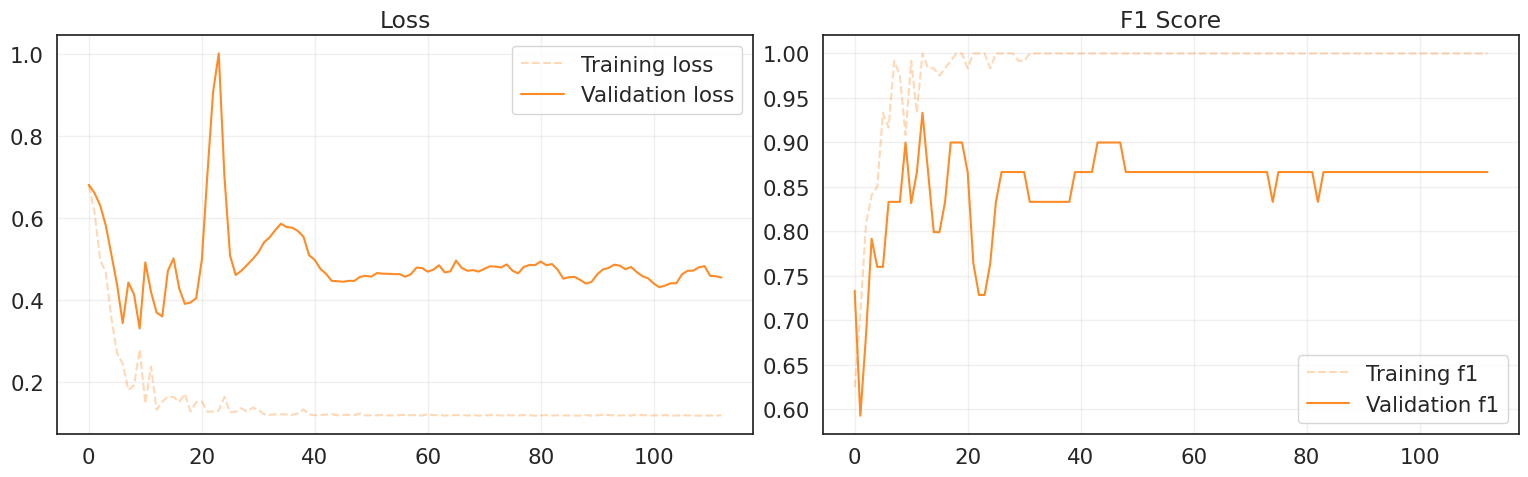

In [ ]:
# Create a figure with two side-by-side subplots (two columns)
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(18, 5))

# Plot of training and validation loss on the first axis
ax1.plot(training_history['train_loss'], label='Training loss', alpha=0.3, color='#ff7f0e', linestyle='--')
ax1.plot(training_history['val_loss'], label='Validation loss', alpha=0.9, color='#ff7f0e')
ax1.set_title('Loss')
ax1.legend()
ax1.grid(alpha=0.3)

# Plot of training and validation accuracy on the second axis
ax2.plot(training_history['train_f1'], label='Training f1', alpha=0.3, color='#ff7f0e', linestyle='--')
ax2.plot(training_history['val_f1'], label='Validation f1', alpha=0.9, color='#ff7f0e')
ax2.set_title('F1 Score')
ax2.legend()
ax2.grid(alpha=0.3)

# Adjust the layout and display the plot
plt.tight_layout()
plt.subplots_adjust(right=0.85)
plt.show()

Accuracy over the validation set: 0.9333
Precision over the validation set: 0.9333
Recall over the validation set: 0.9333
F1 score over the validation set: 0.9333


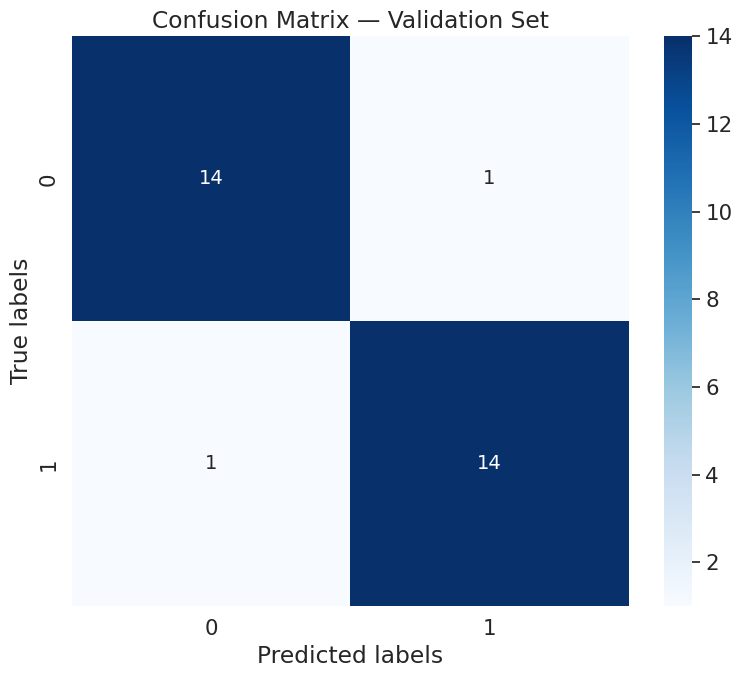

In [ ]:
# Collect predictions and ground truth labels
val_preds, val_targets = [], []

with torch.no_grad():  # Disable gradient computation
    for xb_dyn, xb_static, yb in val_loader:
        # Move data to device
        xb_dyn = xb_dyn.to(device).float()
        xb_static = xb_static.to(device).float()
        yb = yb.to(device)

        # Forward pass: get model predictions
        logits = model(xb_dyn, xb_static)
        preds = logits.argmax(dim=1).cpu().numpy()

        # Store batch results
        val_preds.append(preds)
        val_targets.append(yb.cpu().numpy())

# Combine all batches into single arrays
val_preds = np.concatenate(val_preds)
val_targets = np.concatenate(val_targets)

# Calculate overall validation metrics
val_acc = accuracy_score(val_targets, val_preds)
val_prec = precision_score(val_targets, val_preds, average='weighted')
val_rec = recall_score(val_targets, val_preds, average='weighted')
val_f1 = f1_score(val_targets, val_preds, average='weighted')

print(f"Accuracy over the validation set: {val_acc:.4f}")
print(f"Precision over the validation set: {val_prec:.4f}")
print(f"Recall over the validation set: {val_rec:.4f}")
print(f"F1 score over the validation set: {val_f1:.4f}")

# Generate confusion matrix for detailed error analysis
cm = confusion_matrix(val_targets, val_preds)

# Create numeric labels for heatmap annotation
labels = np.array([f"{num}" for num in cm.flatten()]).reshape(cm.shape)

# Visualize confusion matrix
plt.figure(figsize=(8, 7))
sns.heatmap(cm, annot=labels, fmt='', cmap='Blues')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix — Validation Set')
plt.tight_layout()
plt.show()

## StratifiedGroupKFold and Random Splits


In [ ]:
# from sklearn.model_selection import StratifiedGroupKFold
# from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
# import numpy as np
# import torch

# N_SPLITS = 5
# N_REPEATS = 3
# SEED = 42

# all_metrics = []
# subjects = df_subjects['sample_index'].values
# labels = df_subjects['label'].values

# for repeat in range(N_REPEATS):
#     sgkf = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED + repeat)

#     for fold, (train_idx, val_idx) in enumerate(sgkf.split(df_subjects, labels, groups=subjects)):
#         print(f"\n--- Repeat {repeat+1}, Fold {fold+1} ---")

#         train_users = df_subjects.iloc[train_idx]['sample_index'].values
#         val_users = df_subjects.iloc[val_idx]['sample_index'].values

#         df_train_fold = X_train[X_train['sample_index'].isin(train_users)]
#         df_val_fold = X_train[X_train['sample_index'].isin(val_users)]
#         y_train_fold = y_train[y_train['sample_index'].isin(train_users)]
#         y_val_fold = y_train[y_train['sample_index'].isin(val_users)]

#         X_train_seq, X_train_static, y_train_seq = build_sequences(df_train_fold, y_train_fold, augment=True)
#         X_val_seq, X_val_static, y_val_seq = build_sequences(df_val_fold, y_val_fold, augment=False)

#         train_ds = PirateDataset(X_train_seq, X_train_static, y_train_seq)
#         val_ds = PirateDataset(X_val_seq, X_val_static, y_val_seq)

#         train_loader = make_loader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
#         val_loader = make_loader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

#         model = CNN_GRU_Binary(
#           input_size_dynamic=X_train_seq.shape[-1],
#           input_size_static=X_train_static.shape[-1],
#           hidden_size=HIDDEN_SIZE,
#           num_layers=HIDDEN_LAYERS,
#           dropout_rate=DROPOUT_RATE,
#           bidirectional=False,
#           use_attention=True
#       ).to(device)

#         optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
#         scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
#             optimizer, mode='max', factor=0.5, patience=15
#         )
#         scaler = torch.cuda.amp.GradScaler() if torch.cuda.is_available() else None

#         model, history = fit(
#             model, train_loader, val_loader,
#             epochs=EPOCHS,
#             criterion=criterion,
#             optimizer=optimizer,
#             scaler=scaler,
#             device=device,
#             l1_lambda=L1_LAMBDA,
#             l2_lambda=L2_LAMBDA,
#             patience=PATIENCE,
#             evaluation_metric='val_f1',
#             mode='max',
#             restore_best_weights=True,
#             verbose=10,
#             experiment_name=f"repeat{repeat+1}_fold{fold+1}",
#             base_path=BASE_PATH,
#             scheduler=scheduler  # pass scheduler to fit
#         )

#         # evaluate on validation fold
#         val_preds, val_targets = [], []
#         with torch.no_grad():
#             for xb_dyn, xb_static, yb in val_loader:
#                 xb_dyn, xb_static, yb = xb_dyn.to(device).float(), xb_static.to(device).float(), yb.to(device)
#                 logits = model(xb_dyn, xb_static)
#                 preds = logits.argmax(dim=1).cpu().numpy()
#                 val_preds.append(preds)
#                 val_targets.append(yb.cpu().numpy())

#         val_preds = np.concatenate(val_preds)
#         val_targets = np.concatenate(val_targets)

#         acc = accuracy_score(val_targets, val_preds)
#         f1 = f1_score(val_targets, val_preds, average='weighted')
#         prec = precision_score(val_targets, val_preds, average='weighted')
#         rec = recall_score(val_targets, val_preds, average='weighted')

#         all_metrics.append({'repeat': repeat+1, 'fold': fold+1,
#                             'accuracy': acc, 'f1': f1, 'precision': prec, 'recall': rec})

# # summary
# metrics_array = np.array([[m['accuracy'], m['f1'], m['precision'], m['recall']] for m in all_metrics])
# mean_metrics = metrics_array.mean(axis=0)
# std_metrics = metrics_array.std(axis=0)

# print("\n=== Cross-validated results with scheduler ===")
# print(f"Accuracy: {mean_metrics[0]:.4f} ± {std_metrics[0]:.4f}")
# print(f"F1 score: {mean_metrics[1]:.4f} ± {std_metrics[1]:.4f}")
# print(f"Precision: {mean_metrics[2]:.4f} ± {std_metrics[2]:.4f}")
# print(f"Recall: {mean_metrics[3]:.4f} ± {std_metrics[3]:.4f}")


## Optuna


In [ ]:
import optuna
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import f1_score
import numpy as np

def objective(trial):
    hidden_size = trial.suggest_int("hidden_size", 64, 256, step=32)
    num_layers = trial.suggest_int("num_layers", 1, 3)
    dropout_rate = trial.suggest_float("dropout_rate", 0.1, 0.5, step=0.05)
    bidirectional = trial.suggest_categorical("bidirectional", [True, False])
    use_attention = trial.suggest_categorical("use_attention", [True, False])

    learning_rate = trial.suggest_loguniform("learning_rate", 1e-4, 1e-2)
    l1_lambda = trial.suggest_loguniform("l1_lambda", 1e-5, 1e-2)
    l2_lambda = trial.suggest_loguniform("l2_lambda", 1e-5, 1e-2)

    window_size = trial.suggest_int("window_size", 100, 400, step=50)
    stride = trial.suggest_int("stride", 25, 200, step=25)

    batch_size = 64

    sgkf = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=42)
    df_subjects = (X_train[['sample_index']]
        .drop_duplicates()
        .merge(y_train, on='sample_index')
    )

    f1_scores = []

    for train_idx, val_idx in sgkf.split(df_subjects, df_subjects['label'], groups=df_subjects['sample_index']):
        train_users = df_subjects.iloc[train_idx]['sample_index'].values
        val_users = df_subjects.iloc[val_idx]['sample_index'].values

        df_tr = X_train[X_train['sample_index'].isin(train_users)]
        df_val = X_train[X_train['sample_index'].isin(val_users)]

        y_tr = y_train[y_train['sample_index'].isin(train_users)]
        y_val = y_train[y_train['sample_index'].isin(val_users)]

        X_tr_seq, X_tr_static, y_tr_seq = build_sequences(df_tr, y_tr, window=window_size, stride=stride, augment=True)
        X_val_seq, X_val_static, y_val_seq = build_sequences(df_val, y_val, window=window_size, stride=stride, augment=False)

        train_ds = PirateDataset(X_tr_seq, X_tr_static, y_tr_seq)
        val_ds = PirateDataset(X_val_seq, X_val_static, y_val_seq)

        train_loader = make_loader(train_ds, batch_size=batch_size)
        val_loader = make_loader(val_ds, batch_size=batch_size, shuffle=False)

        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        model = CNN_GRU_Binary(
            input_size_dynamic=X_tr_seq.shape[-1],
            input_size_static=X_tr_static.shape[-1],
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout_rate=dropout_rate,
            bidirectional=bidirectional,
            use_attention=use_attention
        ).to(device)

        criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
        optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
        scaler = torch.cuda.amp.GradScaler() if torch.cuda.is_available() else None

        model, history = fit(
            model,
            train_loader,
            val_loader,
            epochs=500,
            criterion=criterion,
            optimizer=optimizer,
            scaler=scaler,
            device=device,
            l1_lambda=l1_lambda,
            l2_lambda=l2_lambda,
            patience=100,
            evaluation_metric="val_f1",
            mode='max',
            restore_best_weights=True,
            writer=None,
            verbose=0
        )

        val_preds, val_targets = [], []
        with torch.no_grad():
            for xb_dyn, xb_static, yb in val_loader:
                xb_dyn = xb_dyn.to(device).float()
                xb_static = xb_static.to(device).float()
                yb = yb.to(device)
                logits = model(xb_dyn, xb_static)
                preds = logits.argmax(dim=1).cpu().numpy()
                val_preds.append(preds)
                val_targets.append(yb.cpu().numpy())

        val_preds = np.concatenate(val_preds)
        val_targets = np.concatenate(val_targets)
        f1_scores.append(f1_score(val_targets, val_preds, average='weighted'))

    return np.mean(f1_scores)

In [ ]:
study = optuna.create_study(
    direction="maximize",
    study_name="pirate_pain_optuna"
)

n_trials = 30
study.optimize(objective, n_trials=n_trials, n_jobs=1, show_progress_bar=True)

print("Best trial:")
trial = study.best_trial
print(f"F1 Score: {trial.value:.4f}")
print("Params:")
for key, value in trial.params.items():
    print(f"    {key}: {value}")

In [ ]:
import torch
from torch import nn

#  best_params returned by Optuna
# best_params = study.best_trial.params

best_params = {
    'hidden_size': 224,
    'num_layers': 3,
    'dropout_rate': 0.5,
    'bidirectional': False,
    'use_attention': True,
    'learning_rate': 0.0006681049777712333,
    'l1_lambda': 2.2269656369662347e-05,
    'l2_lambda': 0.001482264917853986,
    'window_size': 100,
    'stride': 25
}

# Assign parameters from dictionary
HIDDEN_SIZE = best_params["hidden_size"]
HIDDEN_LAYERS = best_params["num_layers"]
DROPOUT_RATE = best_params["dropout_rate"]
BIDIRECTIONAL = best_params["bidirectional"]
USE_ATTENTION = best_params["use_attention"]
LEARNING_RATE = best_params["learning_rate"]
L1_LAMBDA = best_params["l1_lambda"]
L2_LAMBDA = best_params["l2_lambda"]
WINDOW_SIZE = best_params["window_size"]
STRIDE = best_params["stride"]

# DataLoader settings
BATCH_SIZE = 64
N_SPLITS = 5
N_REPEATS = 3
SEED = 42

all_metrics = []
subjects = df_subjects['sample_index'].values
labels = df_subjects['label'].values

for repeat in range(N_REPEATS):
    sgkf = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED + repeat)

    for fold, (train_idx, val_idx) in enumerate(sgkf.split(df_subjects, labels, groups=subjects)):
        print(f"\n--- Repeat {repeat+1}, Fold {fold+1} ---")

        train_users = df_subjects.iloc[train_idx]['sample_index'].values
        val_users = df_subjects.iloc[val_idx]['sample_index'].values

        df_train_fold = X_train[X_train['sample_index'].isin(train_users)]
        df_val_fold = X_train[X_train['sample_index'].isin(val_users)]
        y_train_fold = y_train[y_train['sample_index'].isin(train_users)]
        y_val_fold = y_train[y_train['sample_index'].isin(val_users)]

        # Build sequences using optimal window and stride
        X_train_seq, X_train_static, y_train_seq = build_sequences(
            df_train_fold, y_train_fold, window=WINDOW_SIZE, stride=STRIDE, augment=True
        )
        X_val_seq, X_val_static, y_val_seq = build_sequences(
            df_val_fold, y_val_fold, window=WINDOW_SIZE, stride=STRIDE, augment=False
        )

        train_ds = PirateDataset(X_train_seq, X_train_static, y_train_seq)
        val_ds = PirateDataset(X_val_seq, X_val_static, y_val_seq)

        train_loader = make_loader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
        val_loader = make_loader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

        # Initialize model with best parameters
        model = CNN_GRU_Binary(
            input_size_dynamic=X_train_seq.shape[-1],
            input_size_static=X_train_static.shape[-1],
            hidden_size=HIDDEN_SIZE,
            num_layers=HIDDEN_LAYERS,
            dropout_rate=DROPOUT_RATE,
            bidirectional=BIDIRECTIONAL,
            use_attention=USE_ATTENTION
        ).to(device)

        optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='max', factor=0.5, patience=15
        )
        # Fix: Always instantiate GradScaler, and control `enabled` parameter
        scaler = torch.cuda.amp.GradScaler(enabled=(device.type == 'cuda'))

        model, history = fit(
            model, train_loader, val_loader,
            epochs=EPOCHS,
            criterion=criterion,
            optimizer=optimizer,
            scaler=scaler,
            device=device,
            l1_lambda=L1_LAMBDA,
            l2_lambda=L2_LAMBDA,
            patience=PATIENCE,
            evaluation_metric='val_f1',
            mode='max',
            restore_best_weights=True,
            verbose=10,
            experiment_name=f"repeat{repeat+1}_fold{fold+1}",
            base_path=BASE_PATH,
            scheduler=scheduler
        )

        # Evaluate on validation fold
        val_preds, val_targets = [], []
        with torch.no_grad():
            for xb_dyn, xb_static, yb in val_loader:
                xb_dyn, xb_static, yb = xb_dyn.to(device).float(), xb_static.to(device).float(), yb.to(device)
                logits = model(xb_dyn, xb_static)
                preds = logits.argmax(dim=1).cpu().numpy()
                val_preds.append(preds)
                val_targets.append(yb.cpu().numpy())

        val_preds = np.concatenate(val_preds)
        val_targets = np.concatenate(val_targets)

        acc = accuracy_score(val_targets, val_preds)
        f1 = f1_score(val_targets, val_preds, average='weighted')
        prec = precision_score(val_targets, val_preds, average='weighted')
        rec = recall_score(val_targets, val_preds, average='weighted')

        all_metrics.append({
            'repeat': repeat+1, 'fold': fold+1,
            'accuracy': acc, 'f1': f1, 'precision': prec, 'recall': rec
        })

# Summary statistics
metrics_array = np.array([[m['accuracy'], m['f1'], m['precision'], m['recall']] for m in all_metrics])
mean_metrics = metrics_array.mean(axis=0)
std_metrics = metrics_array.std(axis=0)

print("\n=== Cross-validated results with Optuna best_params ===")
print(f"Accuracy: {mean_metrics[0]:.4f} \u00b1 {std_metrics[0]:.4f}")
print(f"F1 score: {mean_metrics[1]:.4f} \u00b1 {std_metrics[1]:.4f}")
print(f"Precision: {mean_metrics[2]:.4f} \u00b1 {std_metrics[2]:.4f}")
print(f"Recall: {mean_metrics[3]:.4f} \u00b1 {std_metrics[3]:.4f}")


--- Repeat 1, Fold 1 ---
Training 500 epochs...  (Validation: YES)
Epoch   1/500 | Train: Loss=1.3425, F1=0.5567 | Val: Loss=0.7191, F1=0.3333
Epoch  10/500 | Train: Loss=0.4329, F1=0.9783 | Val: Loss=0.3341, F1=0.8999
Epoch  20/500 | Train: Loss=0.3362, F1=0.9900 | Val: Loss=0.8111, F1=0.7700
Epoch  30/500 | Train: Loss=0.2773, F1=0.9983 | Val: Loss=0.4538, F1=0.8582
Epoch  40/500 | Train: Loss=0.2602, F1=0.9950 | Val: Loss=0.3971, F1=0.8933
Epoch  50/500 | Train: Loss=0.2425, F1=1.0000 | Val: Loss=0.3757, F1=0.8864
Epoch  60/500 | Train: Loss=0.2348, F1=1.0000 | Val: Loss=0.4181, F1=0.8797
Epoch  70/500 | Train: Loss=0.2309, F1=1.0000 | Val: Loss=0.3760, F1=0.8867
Epoch  80/500 | Train: Loss=0.2282, F1=1.0000 | Val: Loss=0.3300, F1=0.9266
Epoch  90/500 | Train: Loss=0.2254, F1=1.0000 | Val: Loss=0.4079, F1=0.8666
Epoch 100/500 | Train: Loss=0.2245, F1=1.0000 | Val: Loss=0.4002, F1=0.8929
Epoch 110/500 | Train: Loss=0.2241, F1=1.0000 | Val: Loss=0.3313, F1=0.9199
Epoch 120/500 | Trai

[Note added when preparing this repository] This cell ended with KeyboardInterrupt during the original Colab run. The traceback was removed for readability; the surrounding cells show the results that were kept.


## Final Model


In [ ]:


EPOCHS = 500
PATIENCE = 100
BASE_PATH = ""

best_params = {
    'hidden_size': 224,
    'num_layers': 3,
    'dropout_rate': 0.5,
    'bidirectional': False,
    'use_attention': True,
    'learning_rate': 0.0006681049777712333,
    'l1_lambda': 2.2269656369662347e-05,
    'l2_lambda': 0.001482264917853986,
    'window_size': 100,
    'stride': 25
}

# Extract parameters
HIDDEN_SIZE   = best_params["hidden_size"]
HIDDEN_LAYERS = best_params["num_layers"]
DROPOUT_RATE  = best_params["dropout_rate"]
BIDIRECTIONAL = best_params["bidirectional"]
USE_ATTENTION = best_params["use_attention"]
LEARNING_RATE = best_params["learning_rate"]
L1_LAMBDA     = best_params["l1_lambda"]
L2_LAMBDA     = best_params["l2_lambda"]
WINDOW_SIZE   = best_params["window_size"]
STRIDE        = best_params["stride"]


X_all_seq, X_all_static, y_all_seq = build_sequences(X_train, y_train,
    window=WINDOW_SIZE,
    stride=STRIDE,
    augment=False   # No augmentation for final training
)

full_ds = PirateDataset(X_all_seq, X_all_static, y_all_seq)
full_loader = make_loader(full_ds, batch_size=BATCH_SIZE, shuffle=True)


model = CNN_GRU_Binary(
    input_size_dynamic=X_all_seq.shape[-1],
    input_size_static=X_all_static.shape[-1],
    hidden_size=HIDDEN_SIZE,
    num_layers=HIDDEN_LAYERS,
    dropout_rate=DROPOUT_RATE,
    bidirectional=BIDIRECTIONAL,
    use_attention=USE_ATTENTION
).to(device)

# Loss (defined BEFORE training)
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)


optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=L2_LAMBDA
)


scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=15
)

# Mixed Precision
scaler = torch.cuda.amp.GradScaler(enabled=(device.type == 'cuda'))


model, history = fit(
    model,
    train_loader=full_loader,
    val_loader=None,          # No validation set: use all data for training
    epochs=EPOCHS,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,      # Will be ignored internally when val_loader=None
    scaler=scaler,
    device=device,
    l1_lambda=L1_LAMBDA,
    l2_lambda=L2_LAMBDA,
    patience=PATIENCE,        # No early stopping, effectively disabled
    evaluation_metric=None,   # No validation metric
    mode="max",
    restore_best_weights=False,
    verbose=10,
    experiment_name="binary_classifier",
    base_path=BASE_PATH
)

**INTEGRAZIONE BINARY CLASSIFIER NELL'ENSEMBLE**

In [ ]:
import os
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

In [ ]:



device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)



best_params = {
    'hidden_size': 224,
    'num_layers': 3,
    'dropout_rate': 0.5,
    'bidirectional': False,
    'use_attention': True,
    'learning_rate': 0.0006681049777712333,
    'l1_lambda': 2.2269656369662347e-05,
    'l2_lambda': 0.001482264917853986,
    'window_size': 100,
    'stride': 25
}

WINDOW = best_params["window_size"]
STRIDE = best_params["stride"]



train_df = pd.read_csv("pirate_pain_train.csv")
train_labels = pd.read_csv("pirate_pain_train_labels.csv")
test_df  = pd.read_csv("pirate_pain_test.csv")

# rimuovo missing rows (come loro)
train_df.dropna(inplace=True)
train_labels.dropna(inplace=True)
test_df.dropna(inplace=True)

# keep low/high only
df_full = train_df.merge(train_labels, on="sample_index")
df_full = df_full[df_full["label"].isin(["low_pain", "high_pain"])]

X_train = df_full.drop(columns=["label"])
y_train = df_full[["sample_index", "label"]]

# static attributes -> numeric mapping
legs_map = {'two':2, 'one+peg_leg':1}
hands_map = {'two':2, 'one+hook_hand':1}
eyes_map = {'two':2, 'one+eye_patch':1}

for df in [X_train, test_df]:
    df["n_legs"]  = df["n_legs"].map(legs_map)
    df["n_hands"] = df["n_hands"].map(hands_map)
    df["n_eyes"]  = df["n_eyes"].map(eyes_map)

# drop constant columns (same as above)
cols_to_drop = [c for c in X_train.columns if X_train[c].nunique()==1]
X_train.drop(columns=cols_to_drop, inplace=True)

# map labels → 0/1
y_train["label"] = y_train["label"].map({"low_pain":0, "high_pain":1})

# cast joints to float32
joint_cols = [c for c in X_train.columns if "joint_" in c]
for df in [X_train, test_df]:
    for c in joint_cols:
        df[c] = df[c].astype(np.float32)



pain_cols = [f"pain_survey_{i+1}" for i in range(4)]
dyn_cols = pain_cols + joint_cols
static_cols = ["n_legs","n_hands","n_eyes"]

means = X_train[dyn_cols].mean()
stds  = X_train[dyn_cols].std()

# applico z-score
X_train[dyn_cols] = (X_train[dyn_cols] - means) / (stds + 1e-8)
test_df[dyn_cols] = (test_df[dyn_cols] - means) / (stds + 1e-8)



def build_sequences(df, y_df=None, window=WINDOW, stride=STRIDE, is_test=False):
    X_seq, X_static, seq_users, y_seq = [], [], [], []

    for sid in df["sample_index"].unique():
        temp = df[df["sample_index"]==sid]
        dyn = temp[dyn_cols].values.astype(np.float32)
        stat = temp[static_cols].iloc[0].values.astype(np.float32)

        # padding identico
        pad_len = (window - len(dyn)%window) % window
        if pad_len>0:
            dyn = np.pad(dyn, ((0,pad_len),(0,0)), mode="edge")

        idx=0
        while idx + window <= len(dyn):
            win = dyn[idx:idx+window]

            X_seq.append(win)
            X_static.append(stat)
            seq_users.append(sid)
            if not is_test:
                y_seq.append(int(y_df[y_df["sample_index"]==sid]["label"].values[0]))
            idx += stride

    X_seq = np.array(X_seq, dtype=np.float32)
    X_static = np.array(X_static, dtype=np.float32)
    seq_users = np.array(seq_users, dtype=np.int32)

    if is_test:
        return X_seq, X_static, seq_users

    return X_seq, X_static, seq_users, np.array(y_seq, dtype=np.int64)



print("\nBuilding TRAIN sequences...")
Xtr_seq, Xtr_stat, users_tr_seq, ytr_seq = build_sequences(X_train, y_train)

print("Building TEST sequences...")
Xte_seq, Xte_stat, users_te_seq = build_sequences(test_df, is_test=True)

print("Train seq:", Xtr_seq.shape)
print("Test  seq:", Xte_seq.shape)



class PirateBinDS(Dataset):
    def __init__(self, Xs, Xst, ys=None, users=None):
        self.Xs= Xs
        self.Xst = Xst
        self.ys = ys
        self.users = users
    def __len__(self): return len(self.Xs)
    def __getitem__(self, i):
        if self.ys is None: return self.Xs[i], self.Xst[i], self.users[i]
        return self.Xs[i], self.Xst[i], self.ys[i], self.users[i]

train_ds = PirateBinDS(Xtr_seq, Xtr_stat, ytr_seq, users_tr_seq)
test_ds  = PirateBinDS(Xte_seq, Xte_stat, None,  users_te_seq)

train_loader = DataLoader(train_ds, batch_size=256, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=256, shuffle=False)



class CNN_GRU_Binary(nn.Module):
    """Model B: CNN + GRU for low vs high pain classification.
    """

    def __init__(
        self,
        input_size_dynamic: int,
        input_size_static: int = 3,
        hidden_size: int = 160,
        num_layers: int = 2,
        dropout_rate: float = 0.3,
        bidirectional: bool = True,
        use_attention: bool = True,
    ):
        super().__init__()

        self.use_attention = use_attention
        gru_input_size = 128

        #  CNN Feature Extractor
        self.cnn = nn.Sequential(
            nn.Conv1d(input_size_dynamic, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Conv1d(64, gru_input_size, kernel_size=3, padding=1),
            nn.BatchNorm1d(gru_input_size),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
        )

        #  GRU Encoder
        self.gru = nn.GRU(
            input_size=gru_input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout_rate if num_layers > 1 else 0,
            bidirectional=bidirectional,
        )

        feat_dim = hidden_size * (2 if bidirectional else 1)

        #  Optional Attention
        if use_attention:
            self.attention = nn.Sequential(
                nn.Linear(feat_dim, 64),
                nn.Tanh(),
                nn.Linear(64, 1, bias=False)
            )

        #  Static Features MLP
        self.static_mlp = nn.Sequential(
            nn.Linear(input_size_static, 16),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
        )
        static_dim = 16

        #  Final Classifier
        self.fc = nn.Sequential(
            nn.Linear(feat_dim + static_dim, 128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(128, 2)  # low vs high
        )

    def forward(self, x_dyn, x_static):
        """
        x_dyn: (batch, seq_len, dynamic_features)
        x_static: (batch, static_features)
        """
        # CNN expects (batch, feat, seq)
        x = x_dyn.permute(0, 2, 1)
        x = self.cnn(x)
        x = x.permute(0, 2, 1)

        # GRU
        out, _ = self.gru(x)

        # Attention or mean pooling
        if self.use_attention:
            attn_weights = torch.softmax(self.attention(out), dim=1)
            seq_embed = torch.sum(out * attn_weights, dim=1)
        else:
            seq_embed = out.mean(dim=1)

        # Static embedding
        static_embed = self.static_mlp(x_static)

        # Combine
        combine = torch.cat([seq_embed, static_embed], dim=1)

        return self.fc(combine)



model_bin = CNN_GRU_Binary(
    input_size_dynamic=Xtr_seq.shape[-1],
    input_size_static=Xtr_stat.shape[-1],
    hidden_size=best_params["hidden_size"],
    num_layers=best_params["num_layers"],
    dropout_rate=best_params["dropout_rate"],
    bidirectional=best_params["bidirectional"],
    use_attention=best_params["use_attention"]
).to(device)

model_bin.load_state_dict(torch.load("models/binary_classifier_model.pt", map_location=device))
model_bin.eval()

print("Binary model loaded!")



def get_logits(loader, is_test=False):
    logits_all = []
    users_all  = []

    with torch.no_grad():
        for batch in tqdm(loader):
            if is_test:
                dyn, stat, u = batch
            else:
                dyn, stat, y, u = batch

            dyn, stat = dyn.to(device), stat.to(device)
            logits = model_bin(dyn, stat).cpu().numpy()

            logits_all.append(logits)
            users_all.append(u.numpy())

    return np.vstack(logits_all), np.concatenate(users_all)

print("\nInference on TRAIN...")
train_logits_seq, train_users_seq = get_logits(train_loader, is_test=False)

print("Inference on TEST...")
test_logits_seq, test_users_seq = get_logits(test_loader, is_test=True)



def aggregate_user_logits(logits_seq, users_seq):
    uniq = np.unique(users_seq)
    user_logits = []

    for uid in uniq:
        idx = np.where(users_seq == uid)[0]
        avg = logits_seq[idx].mean(axis=0)
        user_logits.append(avg)

    return uniq, np.array(user_logits)


train_users_unique, train_logits_user = aggregate_user_logits(train_logits_seq, train_users_seq)
test_users_unique, test_logits_user = aggregate_user_logits(test_logits_seq, test_users_seq)

os.makedirs("logits/binary", exist_ok=True)

np.save("logits/binary/train_logits_bin_user.npy",  train_logits_user)
np.save("logits/binary/train_users_bin_user.npy",   train_users_unique)

np.save("logits/binary/test_logits_bin_user.npy", test_logits_user)

print("Files generated:")
print("   - train_logits_bin_user.npy")
print(train_logits_user.shape)
print("   - train_users_bin_user.npy")
print(train_users_unique.shape)
print("   - test_logits_bin_user.npy")
print(test_logits_user.shape)


Using device: cuda

Building TRAIN sequences...
Building TEST sequences...
Train seq: (750, 100, 34)
Test  seq: (6620, 100, 34)
Binary model loaded!

Inference on TRAIN...


100%|██████████| 3/3 [00:00<00:00, 30.12it/s]


Inference on TEST...


100%|██████████| 26/26 [00:00<00:00, 42.05it/s]



  COMPLETED SUCCESSFULLY
  Files generated:
   - train_logits_bin_user.npy
(150, 2)
   - train_users_bin_user.npy
(150,)
   - test_logits_bin_user.npy
(1324, 2)


In [ ]:
import numpy as np
import pandas as pd


aligned_logits_A = np.load("test_logits_A_9589_final.npy")   # (1324,3)
aligned_logits_B = np.load("test_logits_B_9589_final.npy")   # (1324,3)
aligned_logits_C = np.load("test_logits_C_9589_final.npy")   # (1324,3)

print("A test logits:", aligned_logits_A.shape)
print("B test logits:", aligned_logits_B.shape)
print("C test logits:", aligned_logits_C.shape)



# original labels of the 661 users
y_oof = np.load("oof_logits/oof_labels.npy")            # (661,)
oof_users = np.load("oof_logits/oof_user_ids.npy")      # (661,)

print("OOF y:", y_oof.shape)
print("OOF users:", oof_users.shape)



# 150 low/high users in the binary OOF training set
train_logits_bin = np.load("logits/binary/train_logits_bin_user.npy")   # (150,2)
train_users_bin = np.load("logits/binary/train_users_bin_user.npy")     # (150,)

# 1324 test users
test_logits_bin = np.load("logits/binary/test_logits_bin_user.npy") # (1324,2)

print("Bin train logits:", train_logits_bin.shape)
print("Bin train users:", train_users_bin.shape)
print("Bin test logits:", test_logits_bin.shape)




errors = []



if not (aligned_logits_A.shape[0] == aligned_logits_B.shape[0] == aligned_logits_C.shape[0] == test_logits_bin.shape[0] == 1324):
    errors.append("Test user count does NOT match across A/B/C/BIN")
else:
    print("TEST: all models have 1324 predictions (OK)")


if y_oof.shape[0] != oof_users.shape[0]:
    errors.append(" y_oof and oof_users have different lengths")
else:
    print("OOF: y_oof and oof_users have consistent shapes")


print("Binary OOF has 150 low/high users (expected)")



if aligned_logits_A.shape[1] != 3: errors.append("A logits are not of shape (N,3)")
if aligned_logits_B.shape[1] != 3: errors.append("B logits are not of shape (N,3)")
if aligned_logits_C.shape[1] != 3: errors.append("C logits are not of shape (N,3)")
else:
    print("Logits A/B/C have correct shape (N,3)")

if test_logits_bin.shape[1] != 2:
    errors.append("Binary test logits are not (N,2)")
else:
    print("Binary logits have correct shape (N,2)")



sample_sub = pd.read_csv("sample_submission.csv")
test_users_sub = sample_sub["sample_index"].values

if len(test_users_sub) != aligned_logits_A.shape[0]:
    errors.append("User count in sample_submission does not match the test logits")
else:
    print(" sample_submission has 1324 users (OK)")


# (optional) check that there are no duplicates
if len(np.unique(test_users_sub)) != 1324:
    errors.append(" sample_submission has duplicate users")
else:
    print("No duplicates in sample_submission")




if len(errors) == 0:
    print("All files are consistent and ready for the gate.")
else:
    print( "PROBLEMS FOUND:")
    for e in errors:
        print(" -", e)

print("\nDONE.")

   VALIDATING ENSEMBLE + GATE FILES


--- Loading logits A/B/C ---
A test logits: (1324, 3)
B test logits: (1324, 3)
C test logits: (1324, 3)

--- Loading OOF labels + user order ---
OOF y: (661,)
OOF users: (661,)

--- Loading binary classifier logits ---
Bin train logits: (150, 2)
Bin train users: (150,)
Bin test logits: (1324, 2)

   CONTROLLI DI COERENZA E ALLINEAMENTO

 TEST: all models have 1324 predictions (OK)
 OOF: y_oof and oof_users have consistent shapes
 Binary OOF has 150 low/high users (expected)
 Logits A/B/C have correct shape (N,3)
 Binary logits have correct shape (N,2)

--- Checking test user order ---
 sample_submission has 1324 users (OK)
 No duplicates in sample_submission

               RESULT
 All files are consistent and ready for the gate.

DONE.


In [ ]:
import numpy as np
from sklearn.metrics import f1_score



oof_A = np.load("oof_logits/oof_logits_A.npy")
oof_B = np.load("oof_logits/oof_logits_B.npy")
oof_C = np.load("oof_logits_C.npy")

print("OOF A:", oof_A.shape)
print("OOF B:", oof_B.shape)
print("OOF C:", oof_C.shape)



y_oof = np.load("oof_logits/oof_labels.npy")
oof_users = np.load("oof_logits/oof_user_ids.npy")   # (661,)

print("OOF labels:", y_oof.shape)
print("OOF users:", oof_users.shape)



bin_train_logits = np.load("logits/binary/train_logits_bin_user.npy")  # (150,2)
bin_train_users  = np.load("logits/binary/train_users_bin_user.npy")        # (150,)

bin_test_logits  = np.load("logits/binary/test_logits_bin_user.npy")   # (1324,2)

print("BIN train logits:", bin_train_logits.shape)
print("BIN train users :", bin_train_users.shape)
print("BIN test logits :", bin_test_logits.shape)



test_A = np.load("test_logits_A_9589_final.npy")   # (1324,3)
test_B = np.load("test_logits_B_9589_final.npy")   # (1324,3)
test_C = np.load("test_logits_C_9589_final.npy")   # (1324,3)

print("TEST A:", test_A.shape)
print("TEST B:", test_B.shape)
print("TEST C:", test_C.shape)



      LOAD & VALIDATE ALL FILES

OOF A: (661, 3)
OOF B: (661, 3)
OOF C: (1983, 3)
OOF labels: (661,)
OOF users: (661,)
BIN train logits: (150, 2)
BIN train users : (150,)
BIN test logits : (1324, 2)
TEST A: (1324, 3)
TEST B: (1324, 3)
TEST C: (1324, 3)


Align C's OOF logits at user level

In [ ]:
import numpy as np
import pandas as pd

NUM_CLASSES = 3  # no/low/high

print("=== Loading base OOF (A/B) for user order ===")
oof_users = np.load("oof_logits/oof_user_ids.npy")   # (661,)
print("User ids OOF:", oof_users.shape)

print("\n=== Loading OOF C (window-level) ===")
oof_C_seq   = np.load("oof_logits_C.npy")   # (1983, 3)
oof_users_seq = np.load("oof_users_C.npy")  # (1983,)
print("C window shapes:", oof_C_seq.shape, oof_users_seq.shape)



def aggregate_user_logits(seq_logits, seq_user_ids, num_classes=3):
    df = pd.DataFrame(seq_logits, columns=[f"logit_{k}" for k in range(num_classes)])
    df["user_id"] = seq_user_ids

    df_user = (
        df.groupby("user_id")[ [f"logit_{k}" for k in range(num_classes)] ]
          .mean()
          .reset_index()
          .sort_values("user_id")
    )

    user_ids = df_user["user_id"].values
    user_logits = df_user[[f"logit_{k}" for k in range(num_classes)]].values
    return user_ids, user_logits


user_ids_C, oof_C_user = aggregate_user_logits(
    oof_C_seq,
    oof_users_seq,
    num_classes=NUM_CLASSES
)

print("\nOOF C user-level:", oof_C_user.shape)
print("User ids (C):", len(user_ids_C))




mapC = {uid: i for i, uid in enumerate(user_ids_C)}

aligned_C = np.vstack([
    oof_C_user[mapC[uid]] for uid in oof_users
])

print("Aligned OOF C shape:", aligned_C.shape)


np.save("oof_logits_C_user_aligned.npy", aligned_C)

print("\n Saved: oof_logits_C_user_aligned.npy (shape=", aligned_C.shape, ")")

=== Loading base OOF (A/B) for user order ===
User ids OOF: (661,)

=== Loading OOF C (window-level) ===
C window shapes: (1983, 3) (1983,)

OOF C user-level: (661, 3)
User ids (C): 661

=== Aligning C to oof_users order ===
Aligned OOF C shape: (661, 3)

 Saved: oof_logits_C_user_aligned.npy (shape= (661, 3) )


In [ ]:
import numpy as np
from sklearn.metrics import f1_score



oof_A = np.load("oof_logits/oof_logits_A.npy")
oof_B = np.load("oof_logits/oof_logits_B.npy")
oof_C = np.load("oof_logits_C_user_aligned.npy")

print("OOF A:", oof_A.shape)
print("OOF B:", oof_B.shape)
print("OOF C:", oof_C.shape)



y_oof = np.load("oof_logits/oof_labels.npy")
oof_users = np.load("oof_logits/oof_user_ids.npy")

print("OOF labels:", y_oof.shape)
print("OOF users:", oof_users.shape)



bin_train_logits = np.load("logits/binary/train_logits_bin_user.npy")
bin_train_users  = np.load("logits/binary/train_users_bin_user.npy")

bin_test_logits  = np.load("logits/binary/test_logits_bin_user.npy")

print("BIN train logits:", bin_train_logits.shape)
print("BIN train users :", bin_train_users.shape)
print("BIN test logits :", bin_test_logits.shape)


test_A = np.load("test_logits_A_9589_final.npy")   # (1324,3)
test_B = np.load("test_logits_B_9589_final.npy")   # (1324,3)
test_C = np.load("test_logits_C_9589_final.npy")   # (1324,3)

print("TEST A:", test_A.shape)
print("TEST B:", test_B.shape)
print("TEST C:", test_C.shape)



      LOAD & VALIDATE ALL FILES

OOF A: (661, 3)
OOF B: (661, 3)
OOF C: (661, 3)
OOF labels: (661,)
OOF users: (661,)
BIN train logits: (150, 2)
BIN train users : (150,)
BIN test logits : (1324, 2)
TEST A: (1324, 3)
TEST B: (1324, 3)
TEST C: (1324, 3)


In [ ]:
import numpy as np
from sklearn.metrics import f1_score



def softmax_np(x):
    e = np.exp(x - np.max(x, axis=-1, keepdims=True))
    return e / e.sum(axis=-1, keepdims=True)


wA=0.4412
wB=0.3246
wC=0.2342


logits_ens_oof = (
    wA * oof_A +
    wB * oof_B +
    wC * oof_C
)



print("\nAligning binary users to the ensemble...")

# user -> index map into the binary arrays
bin_map = {uid: i for i, uid in enumerate(bin_train_users)}

# boolean array: True where the user is low/high, i.e. present in the binary set
is_lh = np.array([uid in bin_map for uid in oof_users])

# binary logits aligned to the ensemble OOF order
bin_logits_aligned = np.zeros((661, 2))
bin_available = np.zeros(661, dtype=bool)

for i, uid in enumerate(oof_users):
    if uid in bin_map:
        bin_logits_aligned[i] = bin_train_logits[bin_map[uid]]
        bin_available[i] = True
    else:
        # placeholder (never used on no-pain)
        bin_logits_aligned[i] = [0.5, 0.5]

print("Users with a binary prediction available:", bin_available.sum())


Aligning binary users to the ensemble...
Users with a binary prediction available: 150


In [ ]:
def apply_gate(logits_ens, logits_bin, bin_mask, y_true, alpha, t_conf):
    """
    logits_ens : (N, 3)  logits dell'ensemble A+B+C
    logits_bin : (N, 2)  aligned binary logits (low, high)
    bin_mask   : (N,)    True where a binary (low/high) prediction exists for that user
    y_true     : (N,)    labels vere (0=no, 1=low, 2=high)
    alpha      : float   weight of the binary head in the fusion
    t_conf     : float   max(low/high) confidence at or above which the gate does NOT fire
    """
    N = len(logits_ens)
    preds_final = np.zeros(N, dtype=int)
    debug_logs = []

    total_interventions = 0
    fixes = 0
    worsened = 0
    both_correct = 0
    both_wrong = 0

    ens_correct_total = 0
    gate_correct_total = 0

    for i in range(N):
        p_ens = softmax_np(logits_ens[i])
        ens_pred = int(np.argmax(p_ens))   # 0,1,2
        true = int(y_true[i])

        # accuratezza ensemble "puro"
        if ens_pred == true:
            ens_correct_total += 1

        # Case 1: the ensemble says NO PAIN -> the gate never fires
        if ens_pred == 0:
            final_pred = 0
            preds_final[i] = final_pred
            if final_pred == true:
                gate_correct_total += 1
            # niente log, niente intervento
            continue

        # Caso 2: ensemble dice LOW o HIGH

        # Probabilities renormalised over low/high only
        p_lh_ens = np.array([p_ens[1], p_ens[2]])
        p_lh_ens = p_lh_ens / p_lh_ens.sum()
        max_lh_conf = float(p_lh_ens.max())

        # No binary prediction, or the ensemble is confident -> trust the ensemble
        if (not bin_mask[i]) or (max_lh_conf >= t_conf):
            final_pred = ens_pred
            preds_final[i] = final_pred
            if final_pred == true:
                gate_correct_total += 1
            continue

        # Case 3: the ensemble is NOT confident about low/high -> the gate fires
        total_interventions += 1

        # Binary probabilities (low, high)
        p_bin = softmax_np(logits_bin[i])

        # Fusione pesata low/high
        p_fused = alpha * p_bin + (1.0 - alpha) * p_lh_ens

        # p_fused[0] → low (1), p_fused[1] → high (2)
        pred_lh = 0 if p_fused[0] >= p_fused[1] else 1
        final_pred = 1 + pred_lh
        preds_final[i] = final_pred

        # accuratezza gate finale
        if final_pred == true:
            gate_correct_total += 1

        # Statistiche di confronto ensemble vs gate
        ens_correct = (ens_pred == true)
        gate_correct = (final_pred == true)

        if (not ens_correct) and gate_correct:
            fixes += 1
        elif ens_correct and (not gate_correct):
            worsened += 1
        elif ens_correct and gate_correct:
            both_correct += 1
        else:
            both_wrong += 1

        # Detailed log ONLY when the gate fires
        debug_logs.append({
            "user_idx": i,
            "true_label": true,
            "ensemble_probs": p_ens,
            "ensemble_lh": p_lh_ens,
            "max_lh_conf": max_lh_conf,
            "bin_probs": p_bin,
            "p_fused": p_fused,
            "ensemble_pred": ens_pred,
            "final_pred": final_pred,
        })

    stats = {
        "interventions": total_interventions,
        "fixes": fixes,
        "worsened": worsened,
        "both_correct": both_correct,
        "both_wrong": both_wrong,
        "ensemble_accuracy": ens_correct_total / N,
        "gate_accuracy": gate_correct_total / N,
    }

    return np.array(preds_final), debug_logs, stats

In [ ]:


print("Test shapes:", test_A.shape, test_B.shape, test_C.shape)

logits_ens_test = (
    wA * test_A +
    wB * test_B +
    wC * test_C
)


if bin_test_logits.shape[0] != logits_ens_test.shape[0]:
    raise ValueError("Binary test logits are NOT aligned with the ensemble logits!")

# every test user has a binary prediction -> mask is True everywhere
bin_available_test = np.ones(len(bin_test_logits), dtype=bool)

# dummy ground truth, for compatibility with apply_gate
y_dummy = np.zeros(len(logits_ens_test), dtype=int)


final_preds_test, debug_test, stats_test = apply_gate(
    logits_ens_test,
    bin_test_logits,
    bin_available_test,
    y_dummy,            # not used; only required by the signature
    0.524,        # alpha found during the previous tuning
    0.59
)

print("\nFinal prediction distribution:", np.bincount(final_preds_test))

sample = pd.read_csv("sample_submission.csv")
submission = sample.copy()

# final_preds_test holds 0/1/2 -> map them back to label strings
label_map = {
    0: "no_pain",
    1: "low_pain",
    2: "high_pain"
}

submission["label"] = [label_map[int(x)] for x in final_preds_test]

print(submission["label"].value_counts())


submission.to_csv("submissionBC059test.csv", index=False)

print("\n SUBMISSION SUCCESSFULLY CREATED: submissionBC059test.csv")


       GENERATING TEST SUBMISSION
Test shapes: (1324, 3) (1324, 3) (1324, 3)

Final prediction distribution: [1035  191   98]
label
no_pain      1035
low_pain      191
high_pain      98
Name: count, dtype: int64

 SUBMISSION SUCCESSFULLY CREATED: submissionBC059test.csv
